In [173]:
import albatross_predictions
import matplotlib as mpl

mpl.style.use('default')
mpl.rcParams['axes.linewidth'] = 7  # set the value globally
mpl.rcParams['xtick.major.size'] = 20
mpl.rcParams['xtick.major.width'] = 7
mpl.rcParams['xtick.minor.size'] = 10
mpl.rcParams['xtick.minor.width'] = 7
mpl.rcParams['ytick.major.size'] = 20
mpl.rcParams['ytick.major.width'] = 7
mpl.rcParams['ytick.labelsize'] = 50
mpl.rcParams['xtick.labelsize'] = 50
mpl.rcParams['ytick.minor.size'] = 10
mpl.rcParams['ytick.minor.width'] = 7
mpl.rcParams['font.size'] = 55
mpl.rcParams['font.sans-serif'] = 'Arial'
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['svg.fonttype'] = 'none'

In [119]:
df = albatross_predictions.get_sequence_df(r'W:\OneDrive\Virus\E1A_albatros_predictions', r'W:\OneDrive\Virus\Sequences\E1A_tilepositions.csv')

In [20]:
df

,Unnamed: 0_x,tile,start,end,sequence,PDB code,Virus,Protein,Unnamed: 0_y,length,radius_of_gyration,end_to_end_distance,scaling_exponent,asphericity,prefactor
0,0,1,1,64,MRHIICHGGVITEEMAASLLEQLIEEVLADNLPPPSHFEPPTLHEL...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.976627,60.801277,0.566122,0.463,6.407898
0,9,10,181,244,MFVYSPVSEPEPEPEPEPEPARPTRRPKMVPAILRRPTSPVSRECN...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.763824,60.652828,0.556498,0.430,6.738461
0,10,11,201,264,ARPTRRPKMVPAILRRPTSPVSRECNSSTDSCDSGPSNTPPEIHPV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.842651,62.178566,0.563771,0.452,6.773081
0,11,12,221,284,VSRECNSSTDSCDSGPSNTPPEIHPVVPLCPIKPVAVRVGGRRQAV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.365585,61.389832,0.567170,0.454,6.615514
0,1,2,21,84,EQLIEEVLADNLPPPSHFEPPTLHELYDLDVTAPEDPNEEAVSQIF...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.737545,64.943665,0.571103,0.451,6.638538
0,2,3,41,104,PTLHELYDLDVTAPEDPNEEAVSQIFPDSVMLAVQEGIDLLTFPPA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.715492,63.927959,0.554926,0.442,6.406687
0,3,4,61,124,AVSQIFPDSVMLAVQEGIDLLTFPPASGSPEPPHLSRQPEQPEQRA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.809887,62.607906,0.565833,0.450,6.826369
0,4,5,81,144,LTFPPASGSPEPPHLSRQPEQPEQRALGPVSMPNLVPEVIDLTCHE...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.465721,62.285049,0.555628,0.434,7.106082
0,5,6,101,164,QPEQRALGPVSMPNLVPEVIDLTCHEAGFPPSDDEDEEGEEFVLDY...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,23.510994,53.279842,0.549066,0.429,7.597262
0,6,7,121,184,DLTCHEAGFPPSDDEDEEGEEFVLDYVEQPGHGCRSCHYHRRNTGD...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,21.378674,49.165817,0.490446,0.369,6.896628


In [120]:
from localcider.sequenceParameters import SequenceParameters
import numpy as np
import pandas as pd

In [121]:
aromatics=['F','Y','W']
positives=['R','H','K']
negatives=['D','E']
valines=['V','V']

def countAA(sequence,group):
    count=0
    for aa in sequence:
        if aa in group:
            count +=1
    return count

def get_sequence_parameters(sequence: str) -> dict:
    FCR=SequenceParameters(sequence).get_FCR()
    NCPR=SequenceParameters(sequence).get_NCPR()
    mean_hydropathy=SequenceParameters(sequence).get_mean_hydropathy()
    kappa= SequenceParameters(sequence).get_kappa()
    SCD=SequenceParameters(sequence).get_SCD()
    fraction_disorder_promoting=SequenceParameters(sequence).get_fraction_disorder_promoting()
    countPos=SequenceParameters(sequence).get_countPos()
    countNeut=SequenceParameters(sequence).get_countNeut()
    countNeg=SequenceParameters(sequence).get_countNeg()
    countAro=countAA(sequence,aromatics)
    isoelectric_point=SequenceParameters(sequence).get_isoelectric_point()
    Omega=SequenceParameters(sequence).get_Omega()
    valine=countAA(sequence,valines)

    features = {'sequence':[sequence],
                'FCR':[FCR],
                'NCPR':[NCPR],
                'mean_hydropathy':[mean_hydropathy],
                'kappa': [np.nan] if kappa == -1 else [kappa] ,
                'SCD':SCD,
                'fraction_disorder_promoting':[fraction_disorder_promoting],     
                'countPos':[countPos],
                'countNeut':[countNeut],
                'countNeg':[countNeg],
                'countAro':[countAro],
                'isoelectric_point':[isoelectric_point],
                'Omega':[Omega],
                'valines':[valine]
               }
    return features

def evaluate_sequence_features(sequences: list[str])-> pd.DataFrame:
    df = pd.DataFrame()
    for i in sequences:
        new_df = pd.DataFrame(get_sequence_parameters(i))
        df = pd.concat([df, new_df], ignore_index=True)
    return df

def get_cider_predictions(df, sequence_column):
    sequences = df[sequence_column].unique().tolist()
    sequence_df = evaluate_sequence_features(sequences)
    df = pd.merge(df, sequence_df)
    return df

In [122]:
comp_df = get_cider_predictions(df, 'sequence')
comp_df = comp_df.rename(columns = {'tile': 'construct'})
comp_df = comp_df.reset_index(drop=True).iloc[:, 1:]
comp_df

,construct,start,end,sequence,PDB code,Virus,Protein,Unnamed: 0_y,length,radius_of_gyration,...,kappa,SCD,fraction_disorder_promoting,countPos,countNeut,countNeg,countAro,isoelectric_point,Omega,valines
0,1,1,64,MRHIICHGGVITEEMAASLLEQLIEEVLADNLPPPSHFEPPTLHEL...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.976627,...,0.186898,4.633837,0.640625,1,49,14,2,3.828125,0.159529,4
1,10,181,244,MFVYSPVSEPEPEPEPEPEPARPTRRPKMVPAILRRPTSPVSRECN...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.763824,...,0.398874,-0.570568,0.765625,7,47,10,2,4.593750,0.207887,4
2,11,201,264,ARPTRRPKMVPAILRRPTSPVSRECNSSTDSCDSGPSNTPPEIHPV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.842651,...,0.274155,1.201871,0.718750,11,49,4,0,12.031250,0.048379,7
3,12,221,284,VSRECNSSTDSCDSGPSNTPPEIHPVVPLCPIKPVAVRVGGRRQAV...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.365585,...,0.296631,0.095834,0.640625,5,50,9,0,4.375000,0.035333,7
4,2,21,84,EQLIEEVLADNLPPPSHFEPPTLHELYDLDVTAPEDPNEEAVSQIF...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.737545,...,0.142061,7.131601,0.625000,0,49,15,4,3.281250,0.109102,5
5,3,41,104,PTLHELYDLDVTAPEDPNEEAVSQIFPDSVMLAVQEGIDLLTFPPA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.715492,...,0.183056,4.369618,0.718750,1,50,13,3,3.500000,0.113462,4
6,4,61,124,AVSQIFPDSVMLAVQEGIDLLTFPPASGSPEPPHLSRQPEQPEQRA...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.809887,...,0.198640,1.092327,0.656250,2,54,8,2,3.828125,0.107336,6
7,5,81,144,LTFPPASGSPEPPHLSRQPEQPEQRALGPVSMPNLVPEVIDLTCHE...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,25.465721,...,0.458215,3.365613,0.734375,2,48,14,3,3.609375,0.084289,4
8,6,101,164,QPEQRALGPVSMPNLVPEVIDLTCHEAGFPPSDDEDEEGEEFVLDY...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,23.510994,...,0.467021,0.719603,0.687500,4,46,14,4,4.156250,0.102596,5
9,7,121,184,DLTCHEAGFPPSDDEDEEGEEFVLDYVEQPGHGCRSCHYHRRNTGD...,T1UHH2,Human mastadenovirus C,Early E1A,0,64,21.378674,...,0.479067,0.973498,0.625000,4,46,14,7,4.156250,0.199433,3


In [50]:
basal_cell_df = pd.read_csv(r'E:/Patrick/dataframes/basal_cell_df.csv')

Efret_median = basal_cell_df.groupby(['construct'], as_index=False, observed=True)['Efret'].median()
Efret_std = basal_cell_df.groupby(['construct'], as_index=False, observed=True)['Efret'].std()
Efret_std =Efret_std.rename(columns= {'Efret': 'std'})

plot_df = pd.merge(comp_df, Efret_median, on='construct', how='left')
plot_df = pd.merge(plot_df, Efret_std, on='construct', how='left')


In [96]:
plot_df = plot_df.sort_values(by='construct')

In [114]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.8, 0.25, N)))

def plot_scatter(merged_df, y_column, x_column='Efret'):
    x= merged_df[x_column]
    y=merged_df[y_column]
    error = merged_df['std']

    y_corner = y.max() 
    
    fig, ax  = plt.subplots(figsize=(8, 8))
    mpl.rcParams['figure.dpi'] = 300
    res = stats.linregress(x, y)
    
    ax.plot(x, res.intercept + res.slope*x, 'k')
    for i, b, e in zip(x, y, error):
        ax.scatter(x=i, y=b, edgecolors='k', s=200, zorder=3, linewidths=0.5) 
        ax.errorbar(x=i, y=b, xerr=e, c='gray', alpha=0.2)
    
    r_squared = res.rvalue **2
    ax.tick_params(axis='both', which='major', labelsize=23)
    ax.text( 0.55, y_corner, f'r$^2$= {round(r_squared, 3)}', fontsize=25)
    ax.set_ylabel(y_column, fontsize='xx-large')
    ax.set_xlabel(x_column, fontsize='xx-large')
    plt.savefig(r'D:\OneDrive\Virus\Paper1\New_fig\computational_comparison\\Efret_comparison_to'+ y_column +'.svg' , format='svg', bbox_inches='tight')

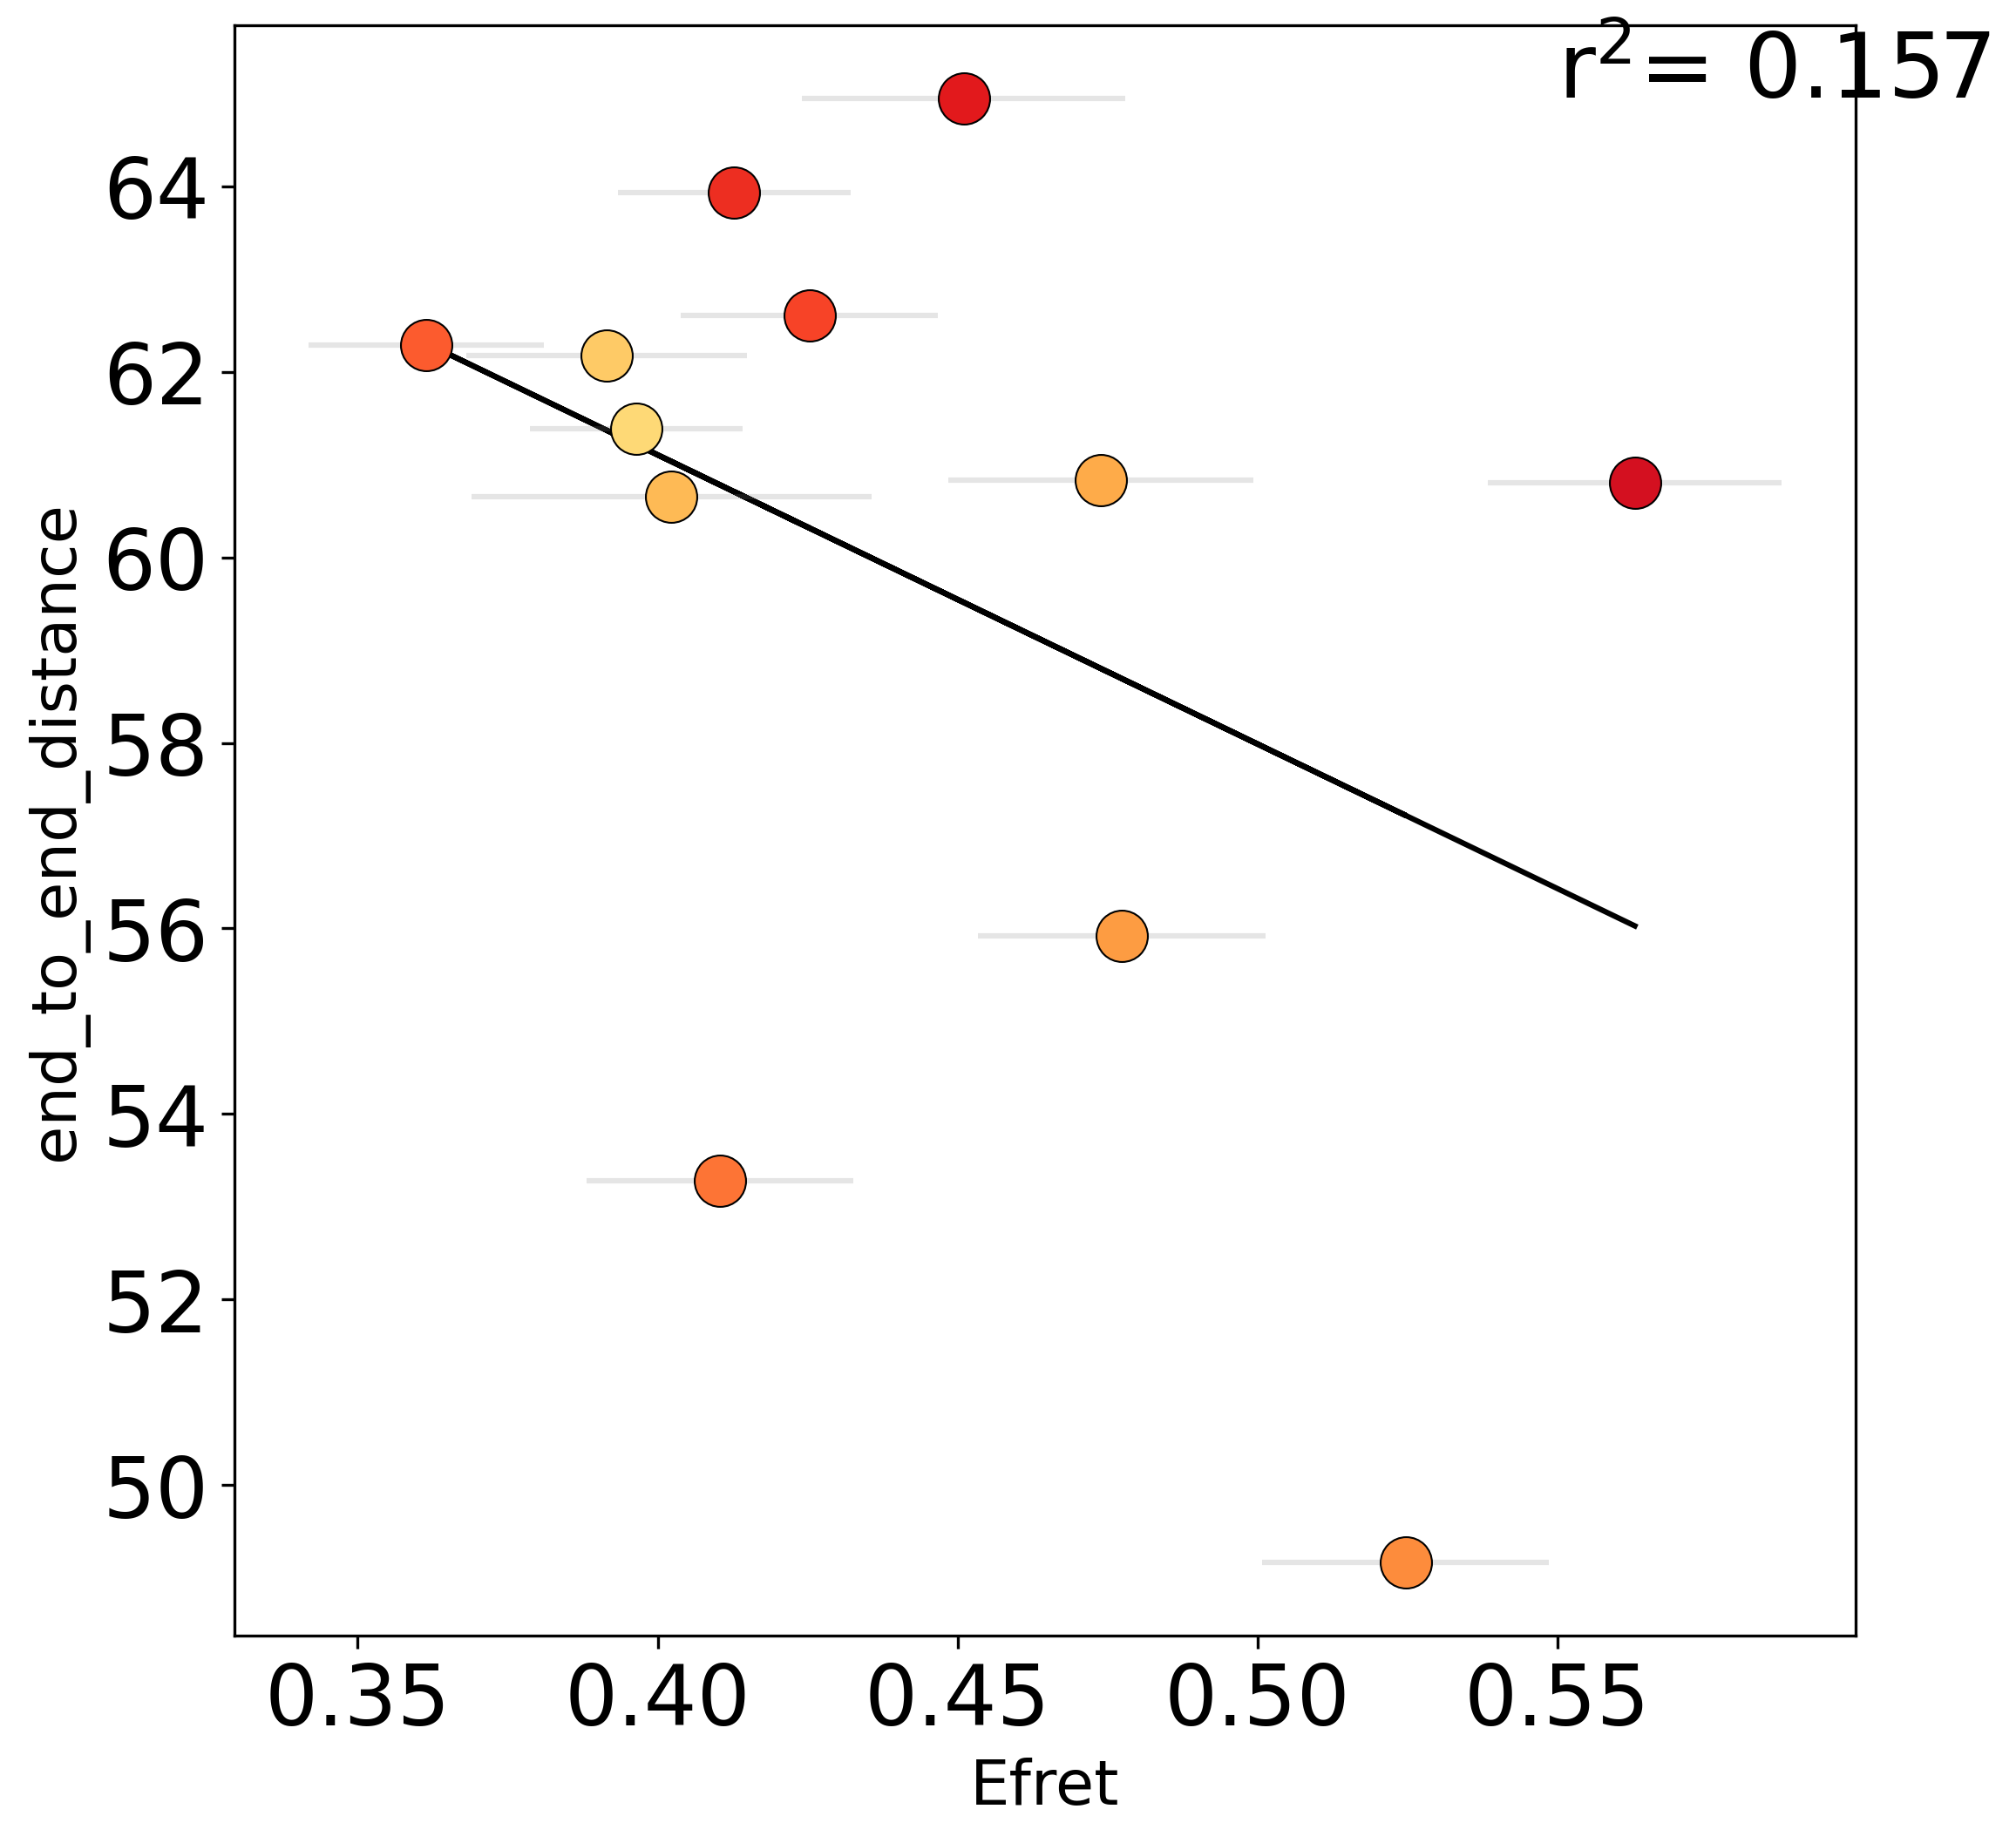

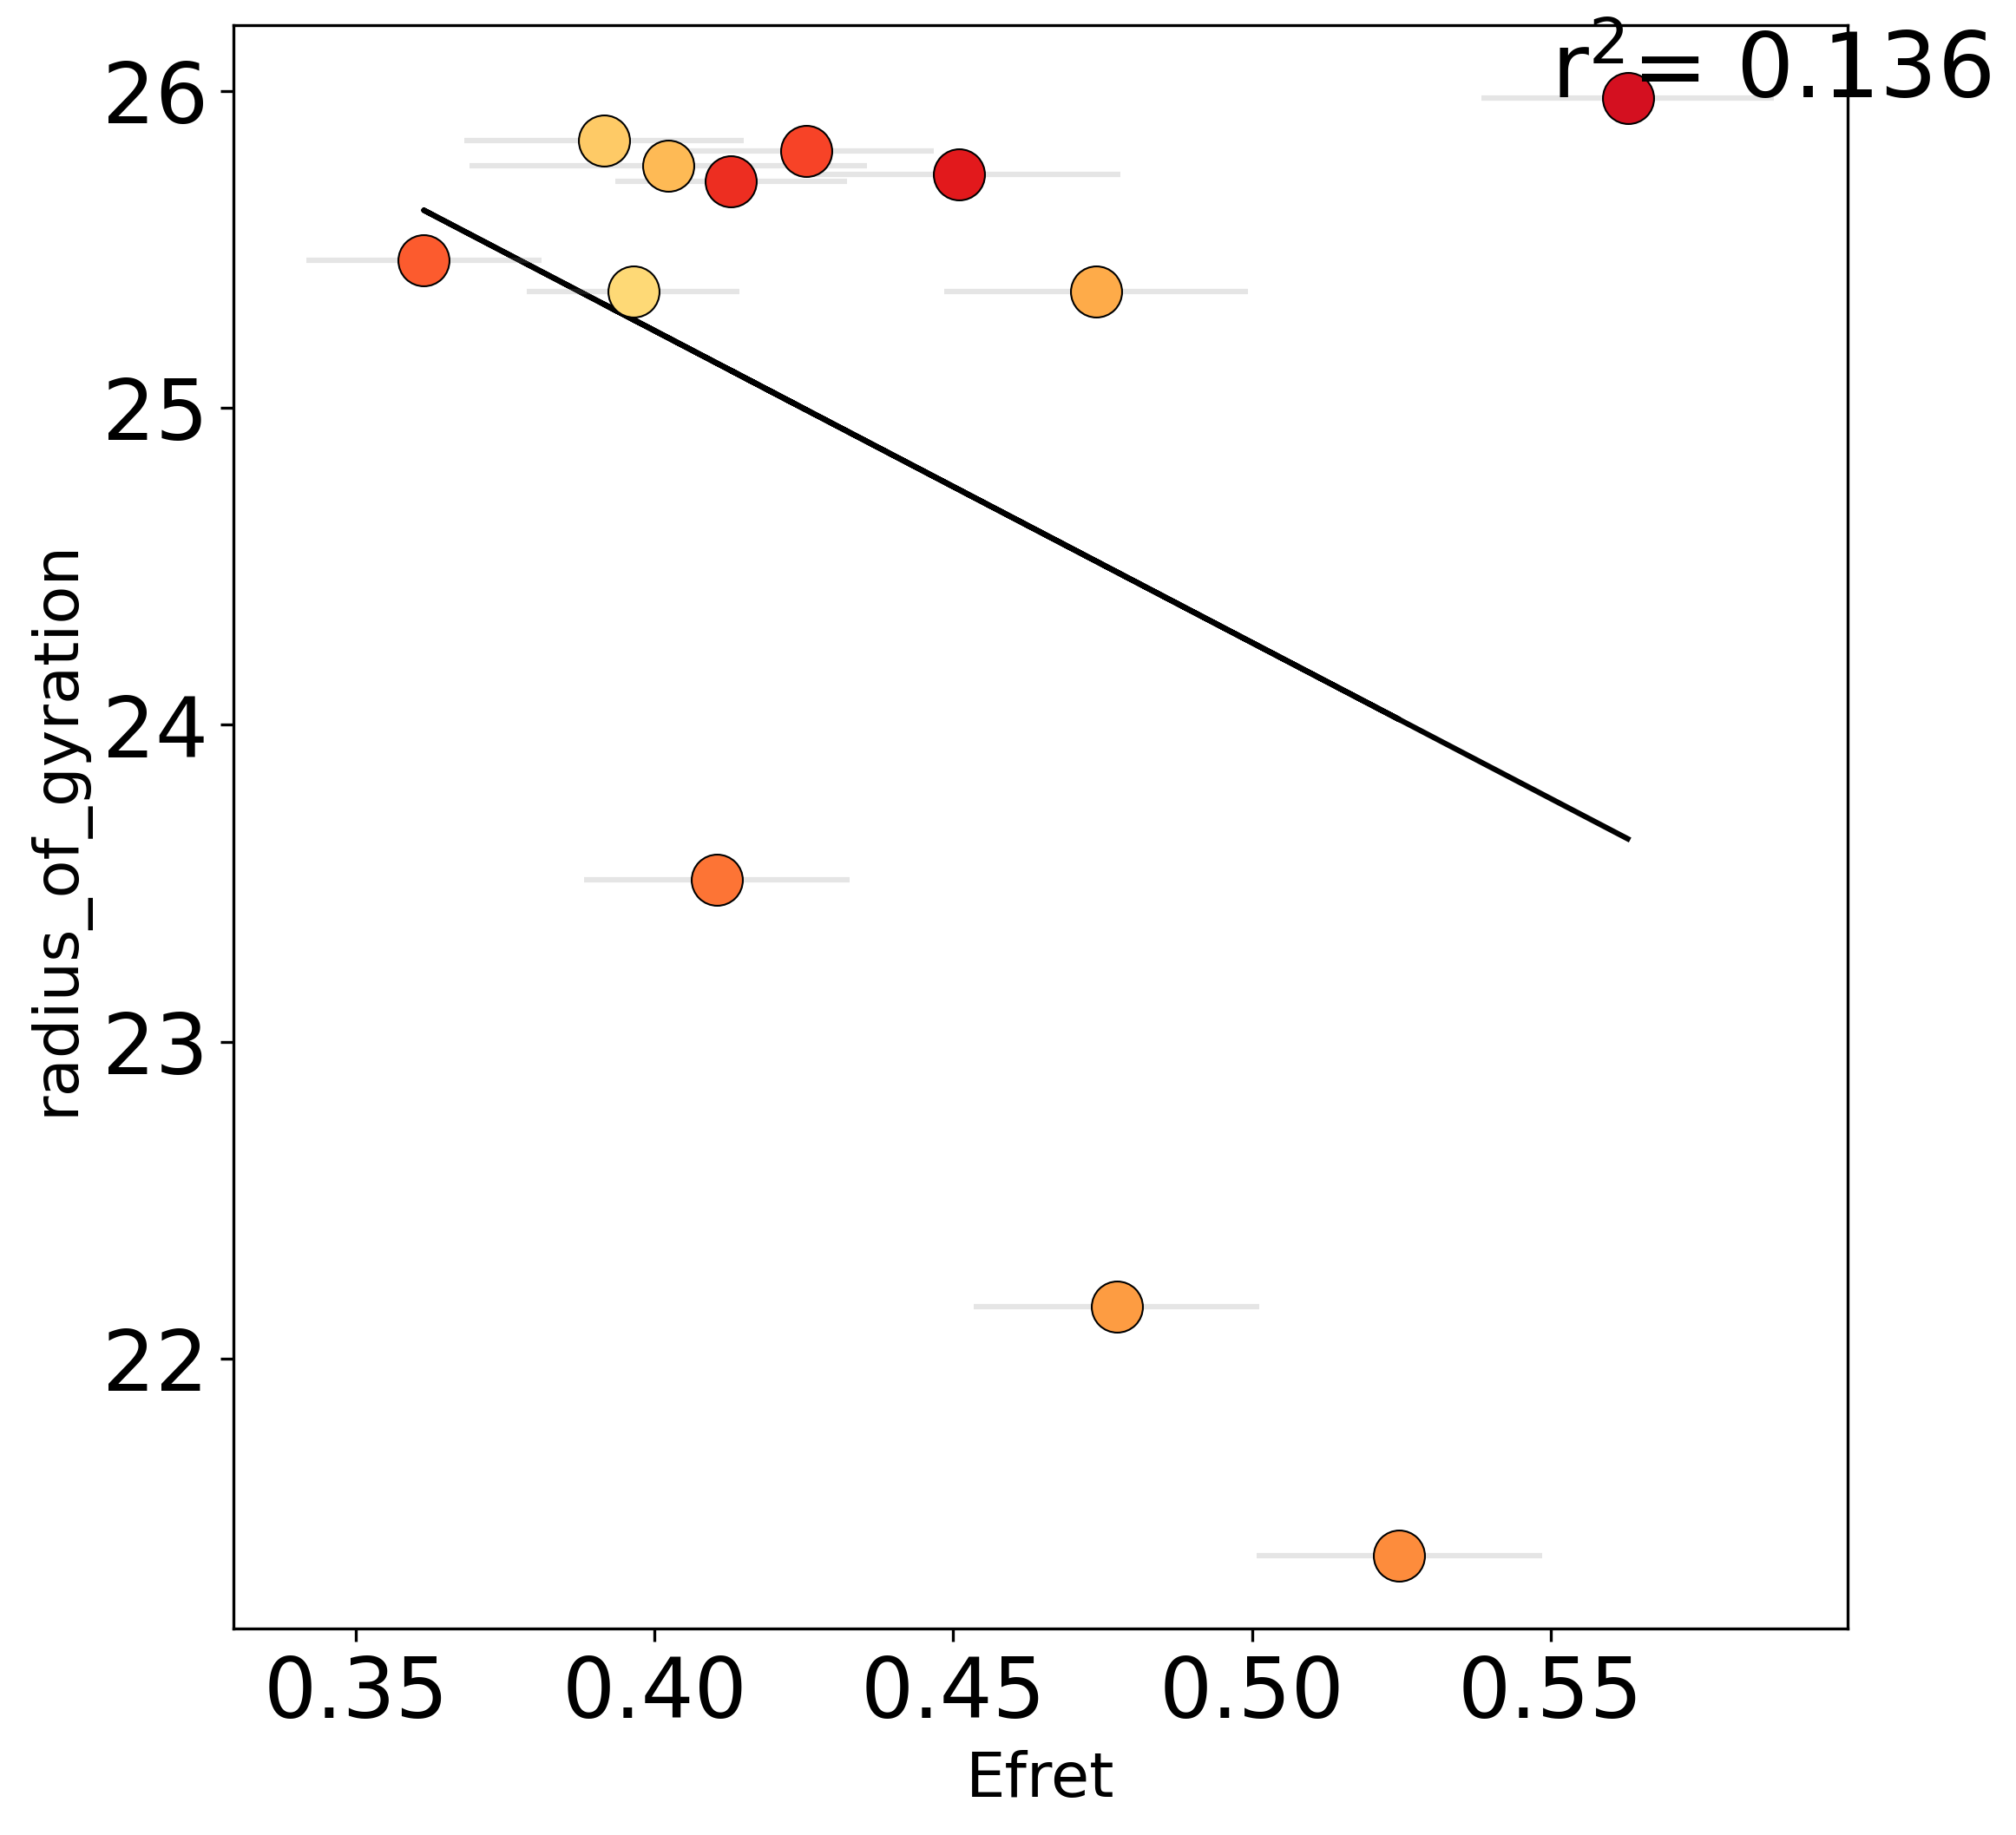

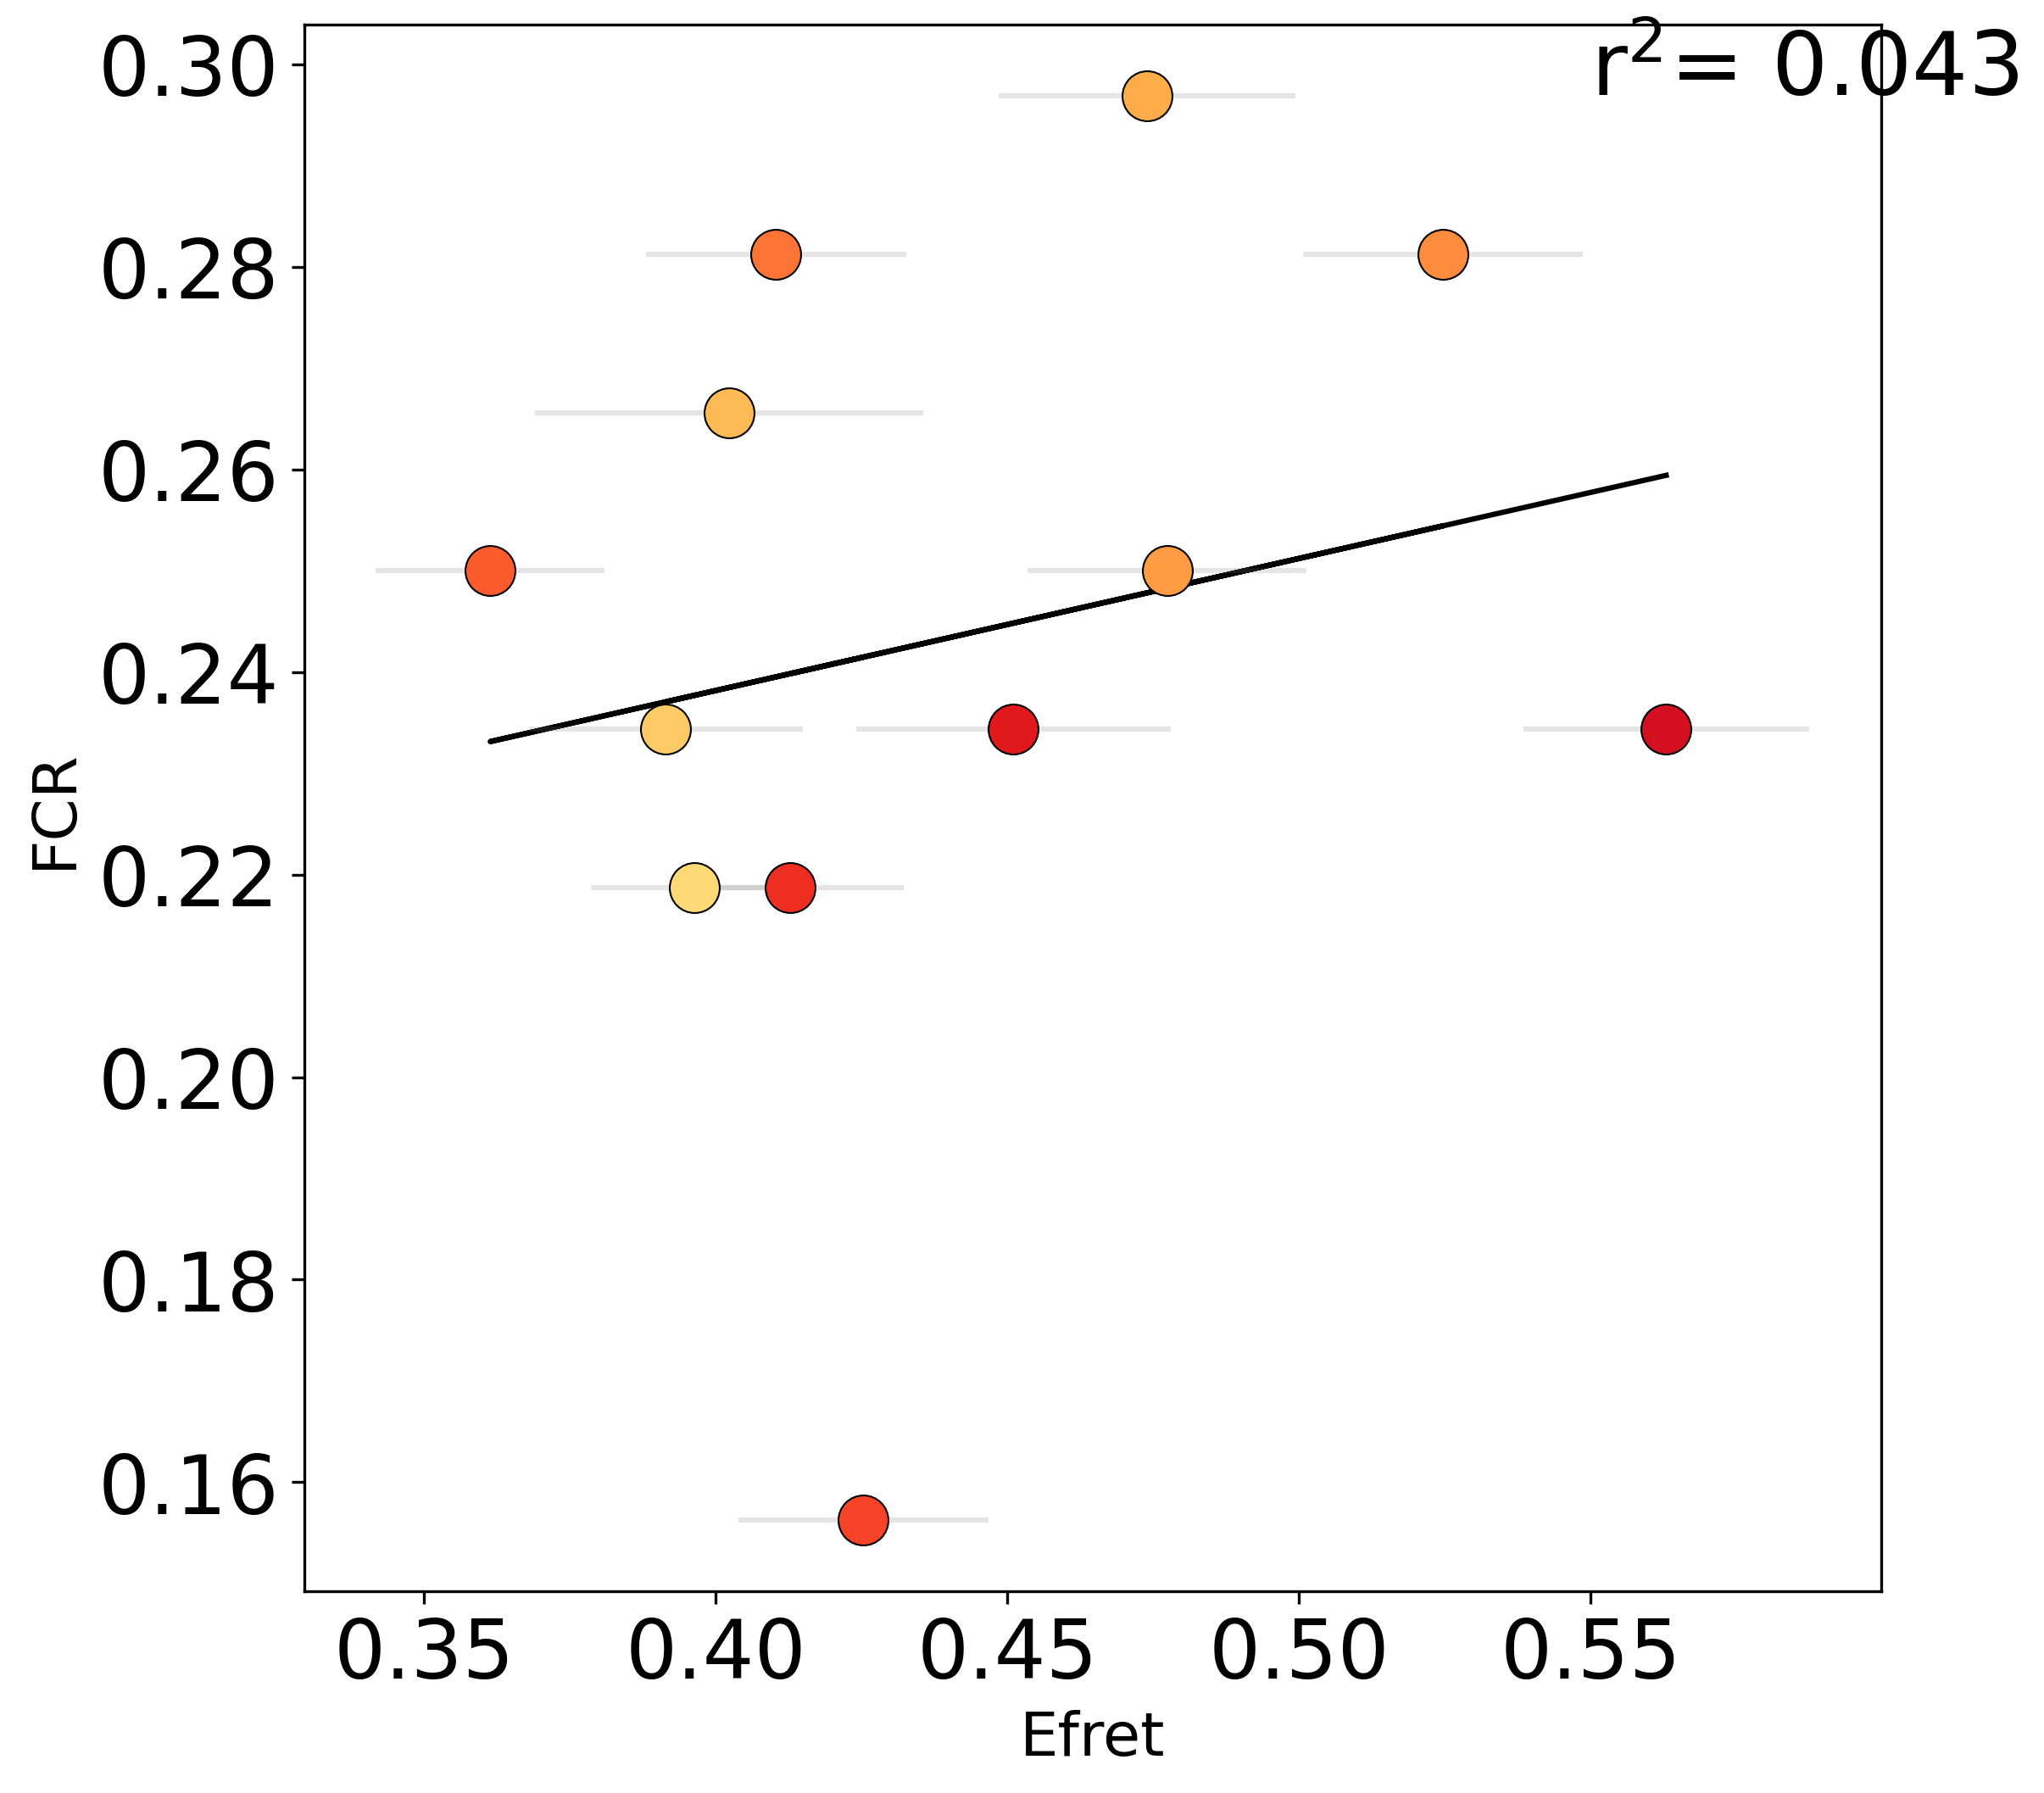

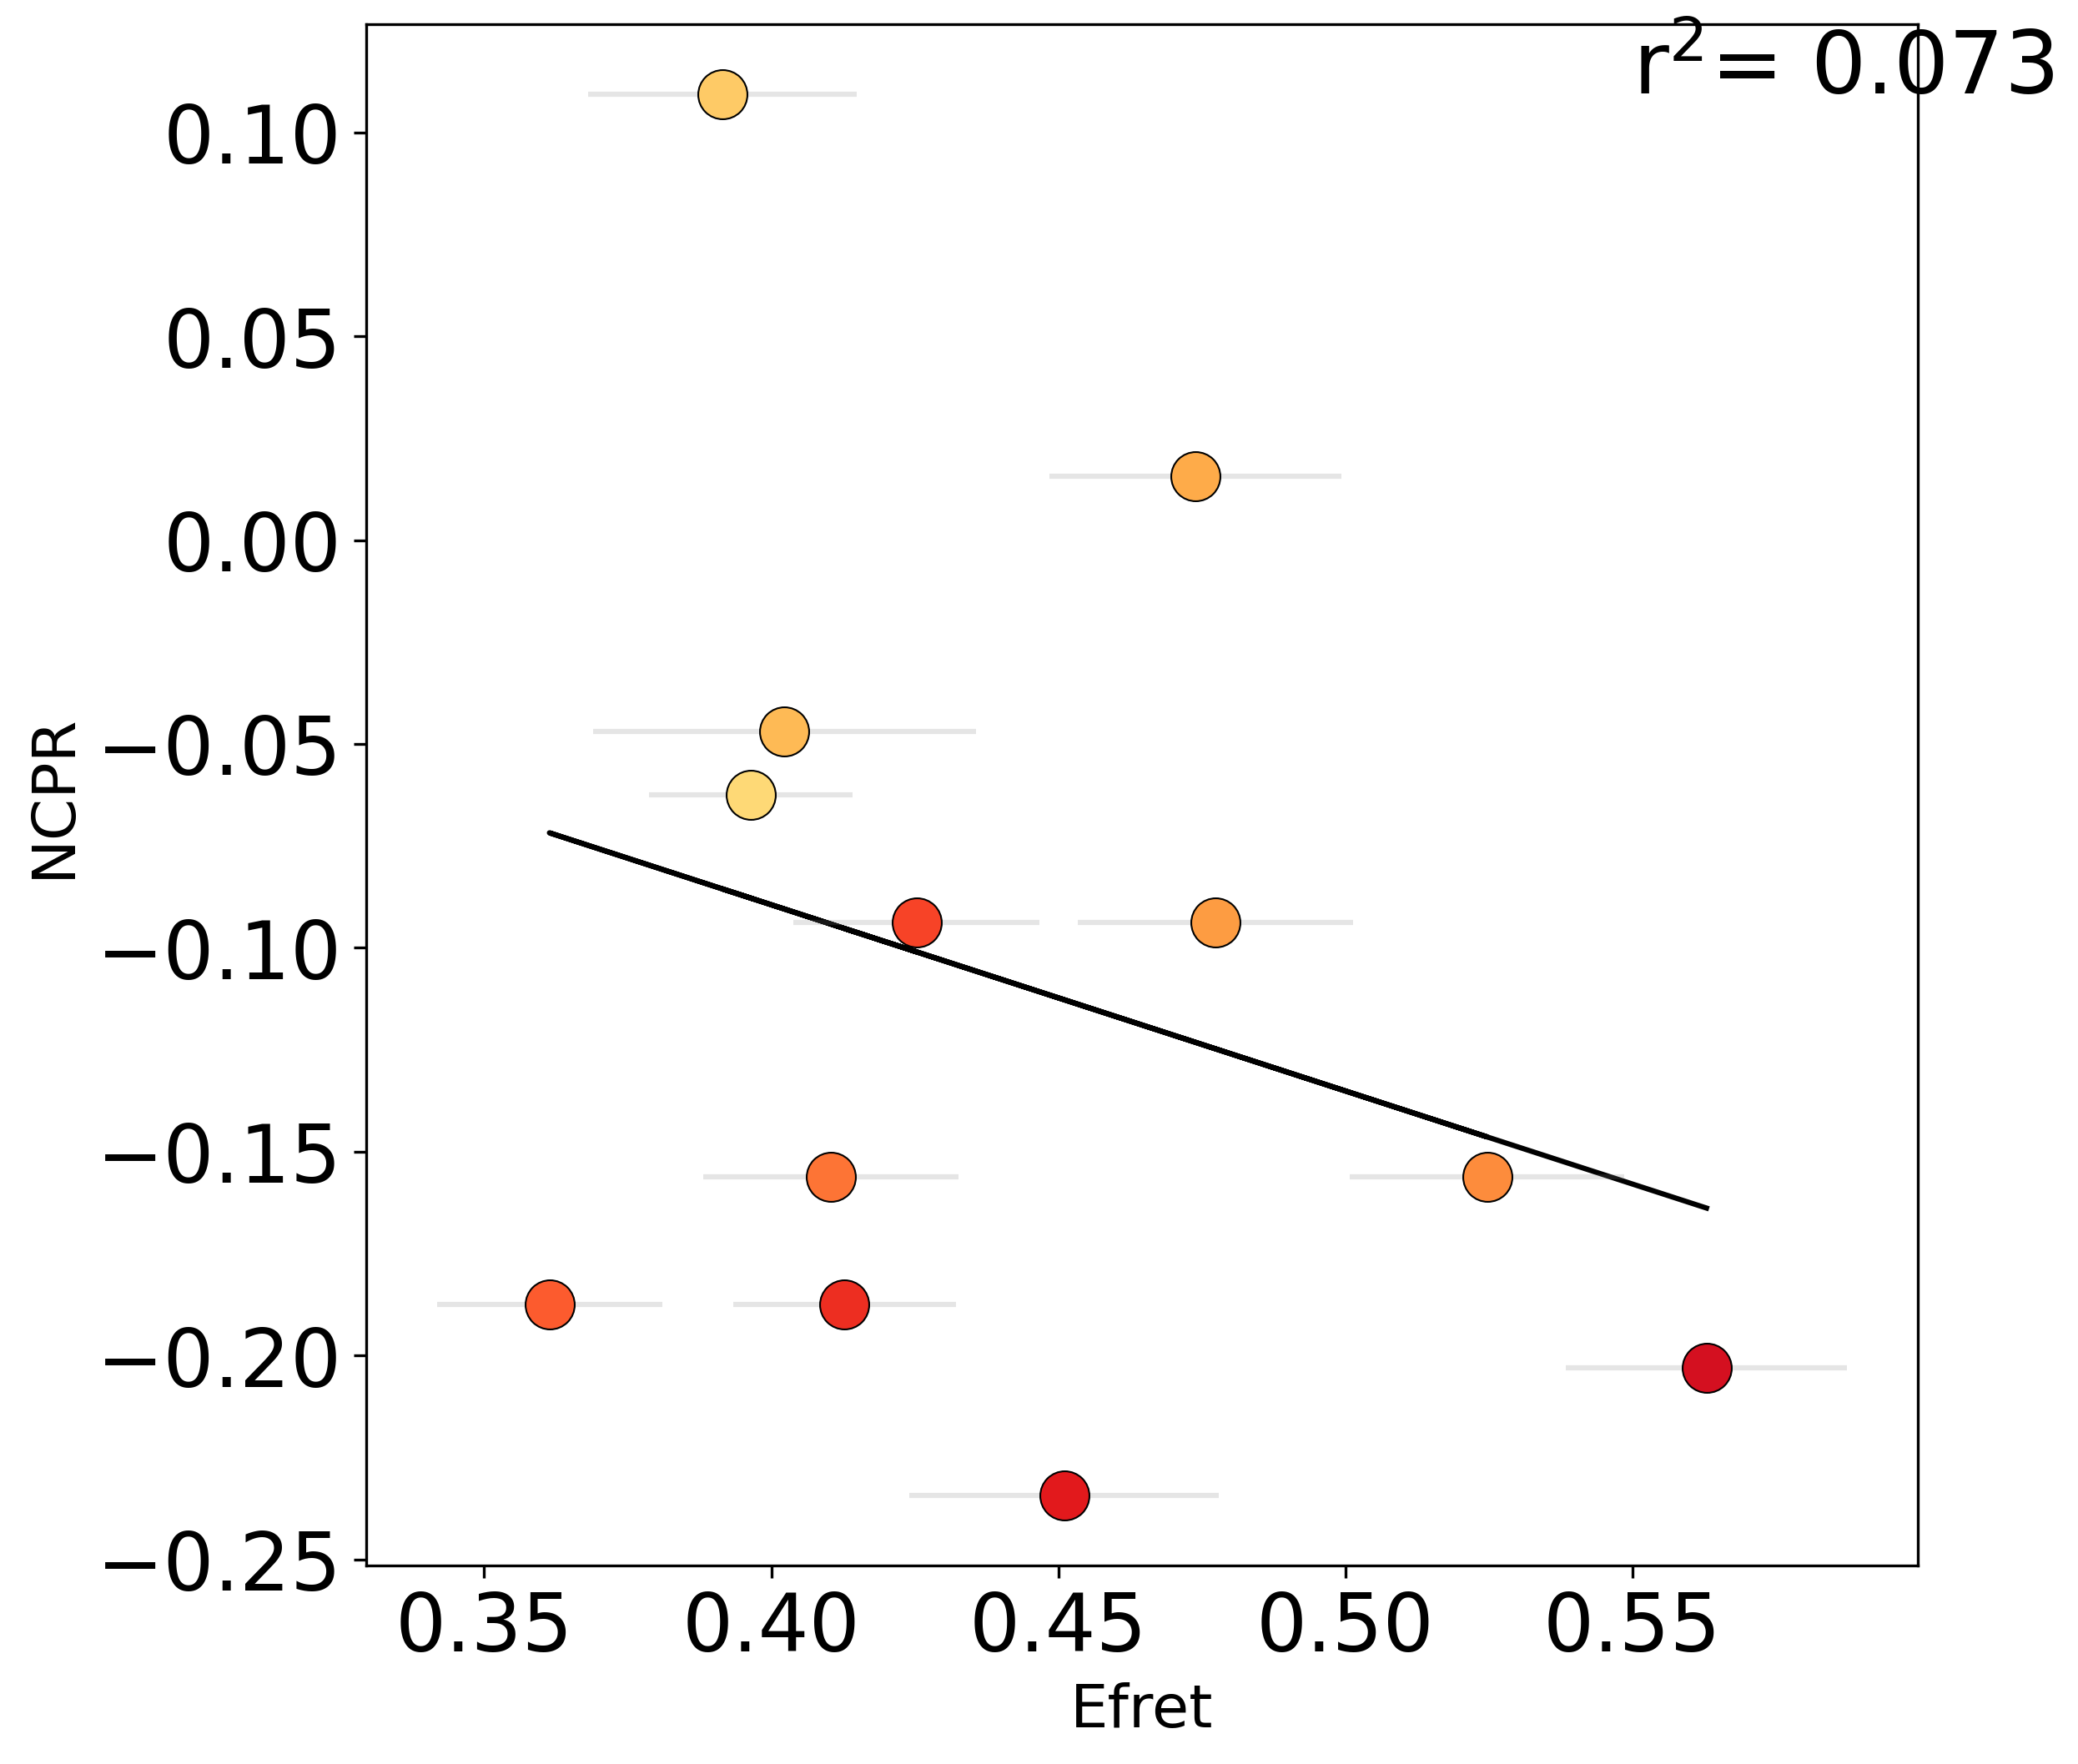

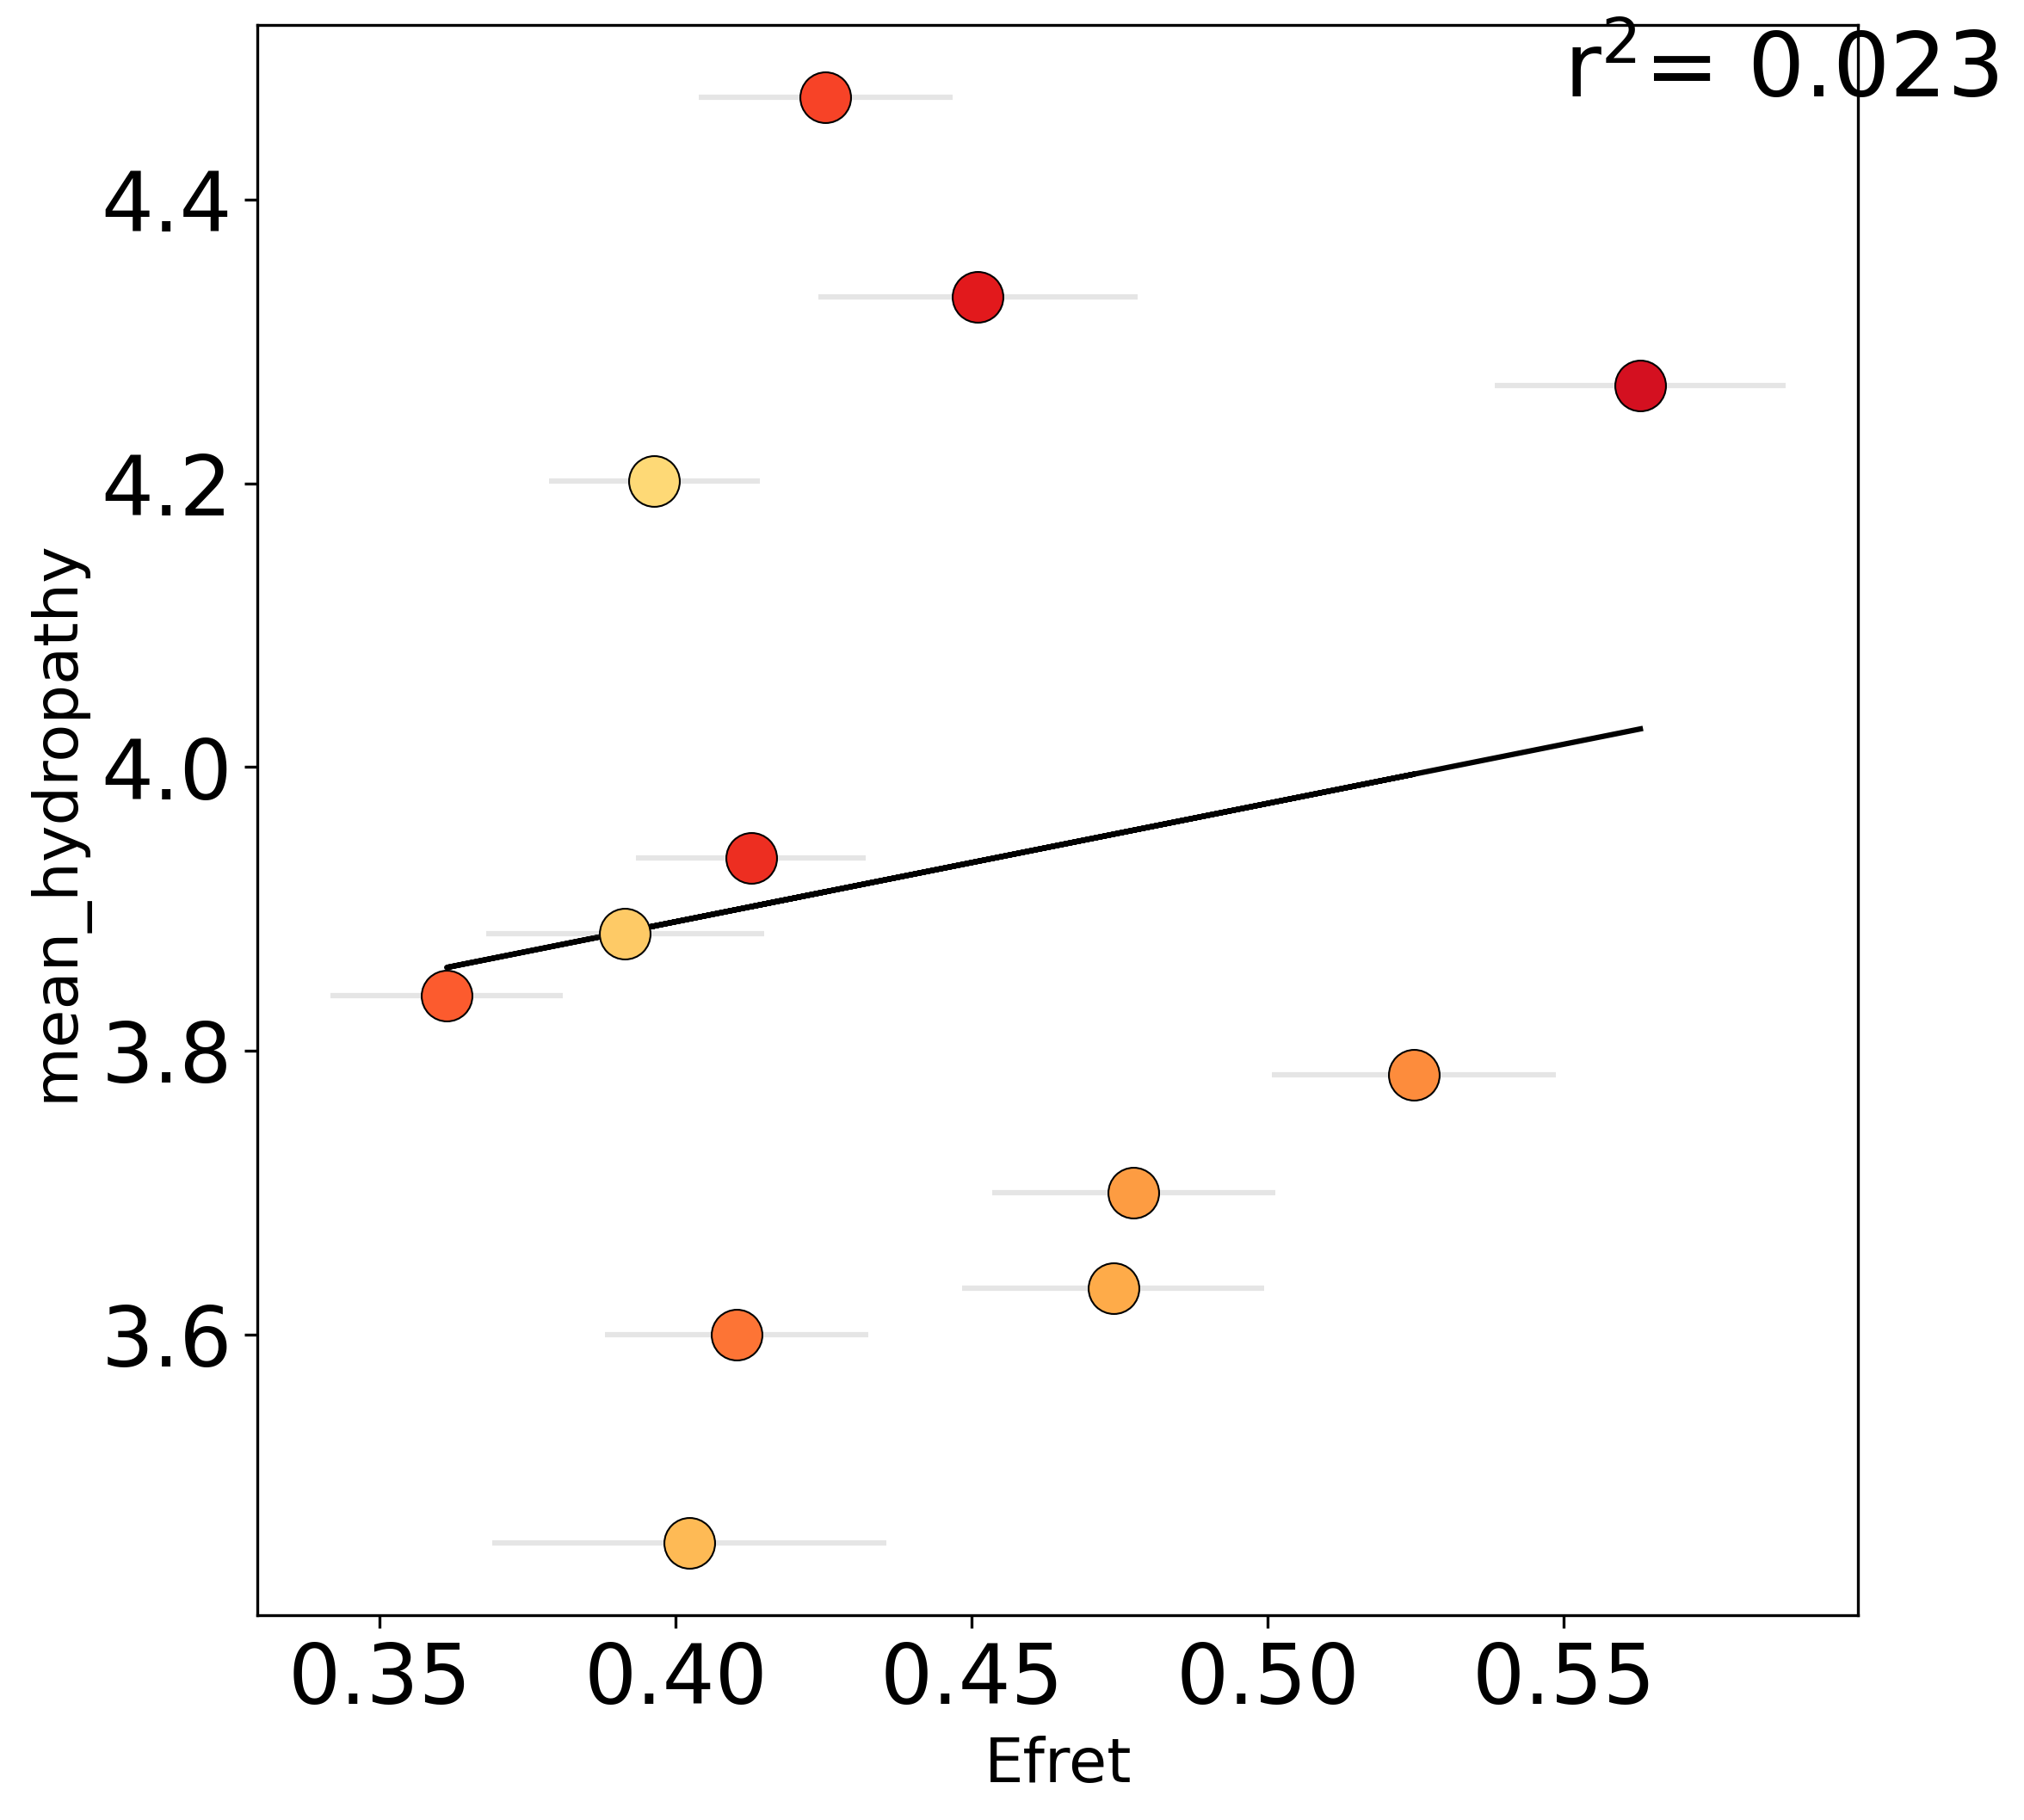

In [115]:

comapre_list = ['end_to_end_distance', 'radius_of_gyration', 'FCR', 'NCPR', 'mean_hydropathy']
for i in comapre_list:
    plot_scatter(plot_df, i)

In [6]:
from cider_predictions import evaluate_sequence_features
import pandas as pd

In [11]:
df = pd.read_csv(r'W:\OneDrive\Virus\Paper1\processed_csvs\e1a_full_length_residues.csv').iloc[:, 1:]
"".join(df.iloc[0: 10, 0].tolist())

'MRHIICHGGV'

In [12]:
df

,Res,Index,Disorder,ppLDDT,sequence
0,M,1,0.694,62.096,E1A
1,R,2,0.636,70.310,E1A
2,H,3,0.538,71.970,E1A
3,I,4,0.420,72.769,E1A
4,I,5,0.333,73.453,E1A
...,...,...,...,...,...
284,K,285,0.812,53.536,E1A
285,R,286,0.836,49.625,E1A
286,P,287,0.801,48.093,E1A
287,R,288,0.750,46.009,E1A


In [75]:
def get_subseq_features(df, seq_spacer: int=10, sequence_column: str="Res"):
    iterations = int(np.ceil(len(df)/seq_spacer))
    iterator_df = df.copy()
    
    df.columns = df.columns.str.strip()
    
    columns = df.columns
    average_ppLDDT = [] if 'ppLDDT' in columns else False
    sequences = []

    position = 1
    for i in range(iterations):
        if len(iterator_df) >= seq_spacer:
            seq_df = iterator_df.iloc[0:seq_spacer]
            iterator_df =iterator_df.iloc[seq_spacer:]
        else:
            seq_df = iterator_df.iloc[0:len(iterator_df)]
            
        sequence = "".join(seq_df[sequence_column].tolist())
        sequences.append(sequence)
        
        if type(average_ppLDDT) == list:
            average_ppLDDT.append(seq_df['ppLDDT'].mean())
        
    sequence_df = evaluate_sequence_features(sequences)
    if not average_ppLDDT:
        return sequence_df
    else:
        sequence_df['average_ppLDDT'] = average_ppLDDT
        return sequence_df

In [76]:
import numpy as np

evaluated_df = get_subseq_features(df)

In [77]:
evaluated_df

,sequence,FCR,NCPR,mean_hydropathy,kappa,SCD,fraction_disorder_promoting,countPos,countNeut,countNeg,countAro,isoelectric_point,Omega,valines,average_ppLDDT
0,MRHIICHGGV,0.100000,0.100000,5.090000,0.941176,0.000000,0.500000,1,9,0,0,10.500000,0.884658,1,72.200300
1,ITEEMAASLL,0.200000,-0.200000,5.410000,0.854545,0.100000,0.600000,0,8,2,0,1.750000,0.560746,0,82.675300
2,DQLIEEVLAD,0.400000,-0.400000,4.560000,0.043478,1.247214,0.600000,0,6,4,0,1.750000,0.006553,1,85.006200
3,NLPPPSHFEP,0.100000,-0.100000,3.420000,0.941176,0.000000,0.700000,0,9,1,1,5.250000,0.003471,0,69.070900
4,PTLHELYDLD,0.300000,-0.300000,3.910000,0.230000,0.538233,0.600000,0,7,3,1,3.718750,0.125203,0,65.827700
5,VTAPEDPNEE,0.400000,-0.400000,2.960000,0.253623,0.996812,0.800000,0,6,4,0,1.750000,0.242620,1,56.914100
6,AVSQIFPDSV,0.100000,-0.100000,5.230000,0.882353,0.000000,0.600000,0,9,1,1,1.750000,0.560746,2,58.911500
7,MLAVQEGIDL,0.200000,-0.200000,5.410000,0.454545,0.173205,0.500000,0,8,2,0,1.750000,0.239139,1,64.576100
8,LTFPPAPGSP,0.000000,0.000000,4.510000,NaN,0.000000,0.800000,0,10,0,1,7.000000,0.004087,0,57.106500
9,EPPHLSRQPE,0.300000,-0.100000,2.500000,0.194805,-0.118154,0.900000,1,7,2,0,5.250000,0.035757,0,47.163200


In [155]:
lin_space = np.linspace(0.2, len(evaluated_df)+.2, len(evaluated_df))
tile_space = np.linspace(3.25, 25.25 , len(comp_df))

Text(0.5, 0, 'Sequence')

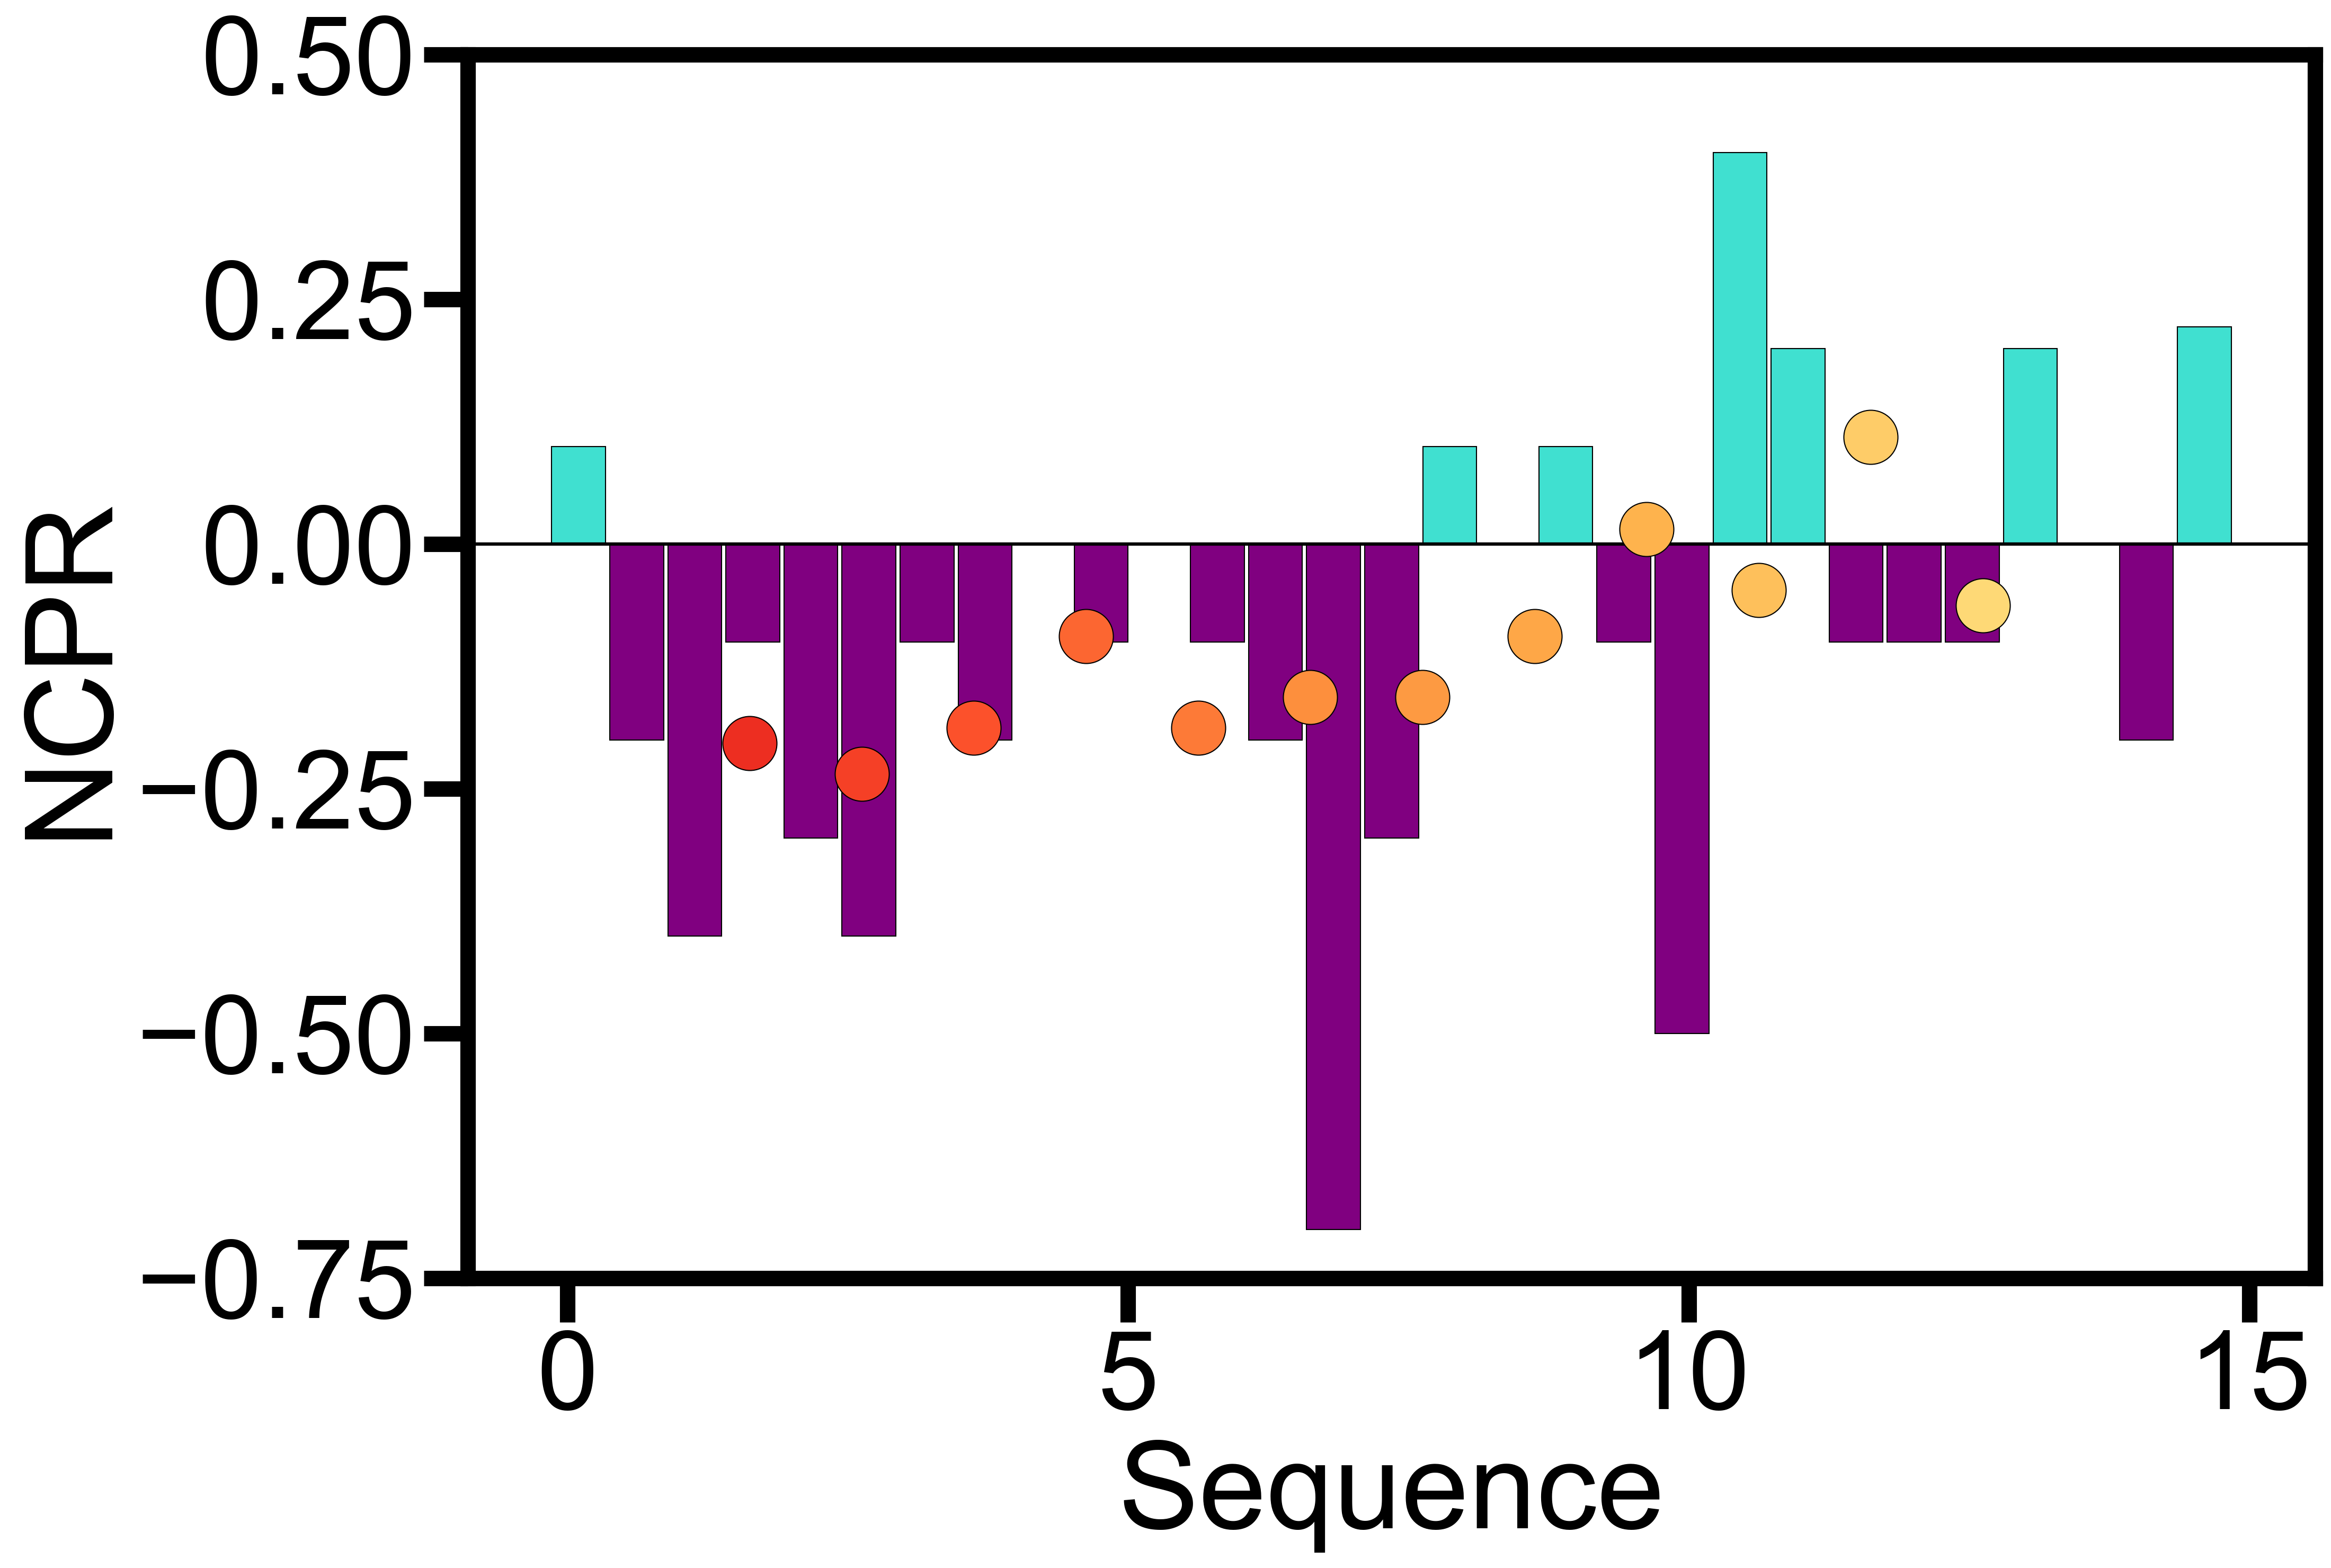

In [175]:


fig, ax = plt.subplots(figsize=(18, 10))
colors = np.where(evaluated_df['NCPR'] >0, 'turquoise', 'purple')

plt.bar(lin_space/2, evaluated_df['NCPR'], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df['NCPR']):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=600, edgecolor='k', linewidth=0.5, zorder=3)
    
plt.axhline(0, c='k')
plt.ylim(-0.75, 0.5)

plt.ylabel('NCPR')
plt.xlabel('Sequence')

Text(0.5, 0, 'Sequence')

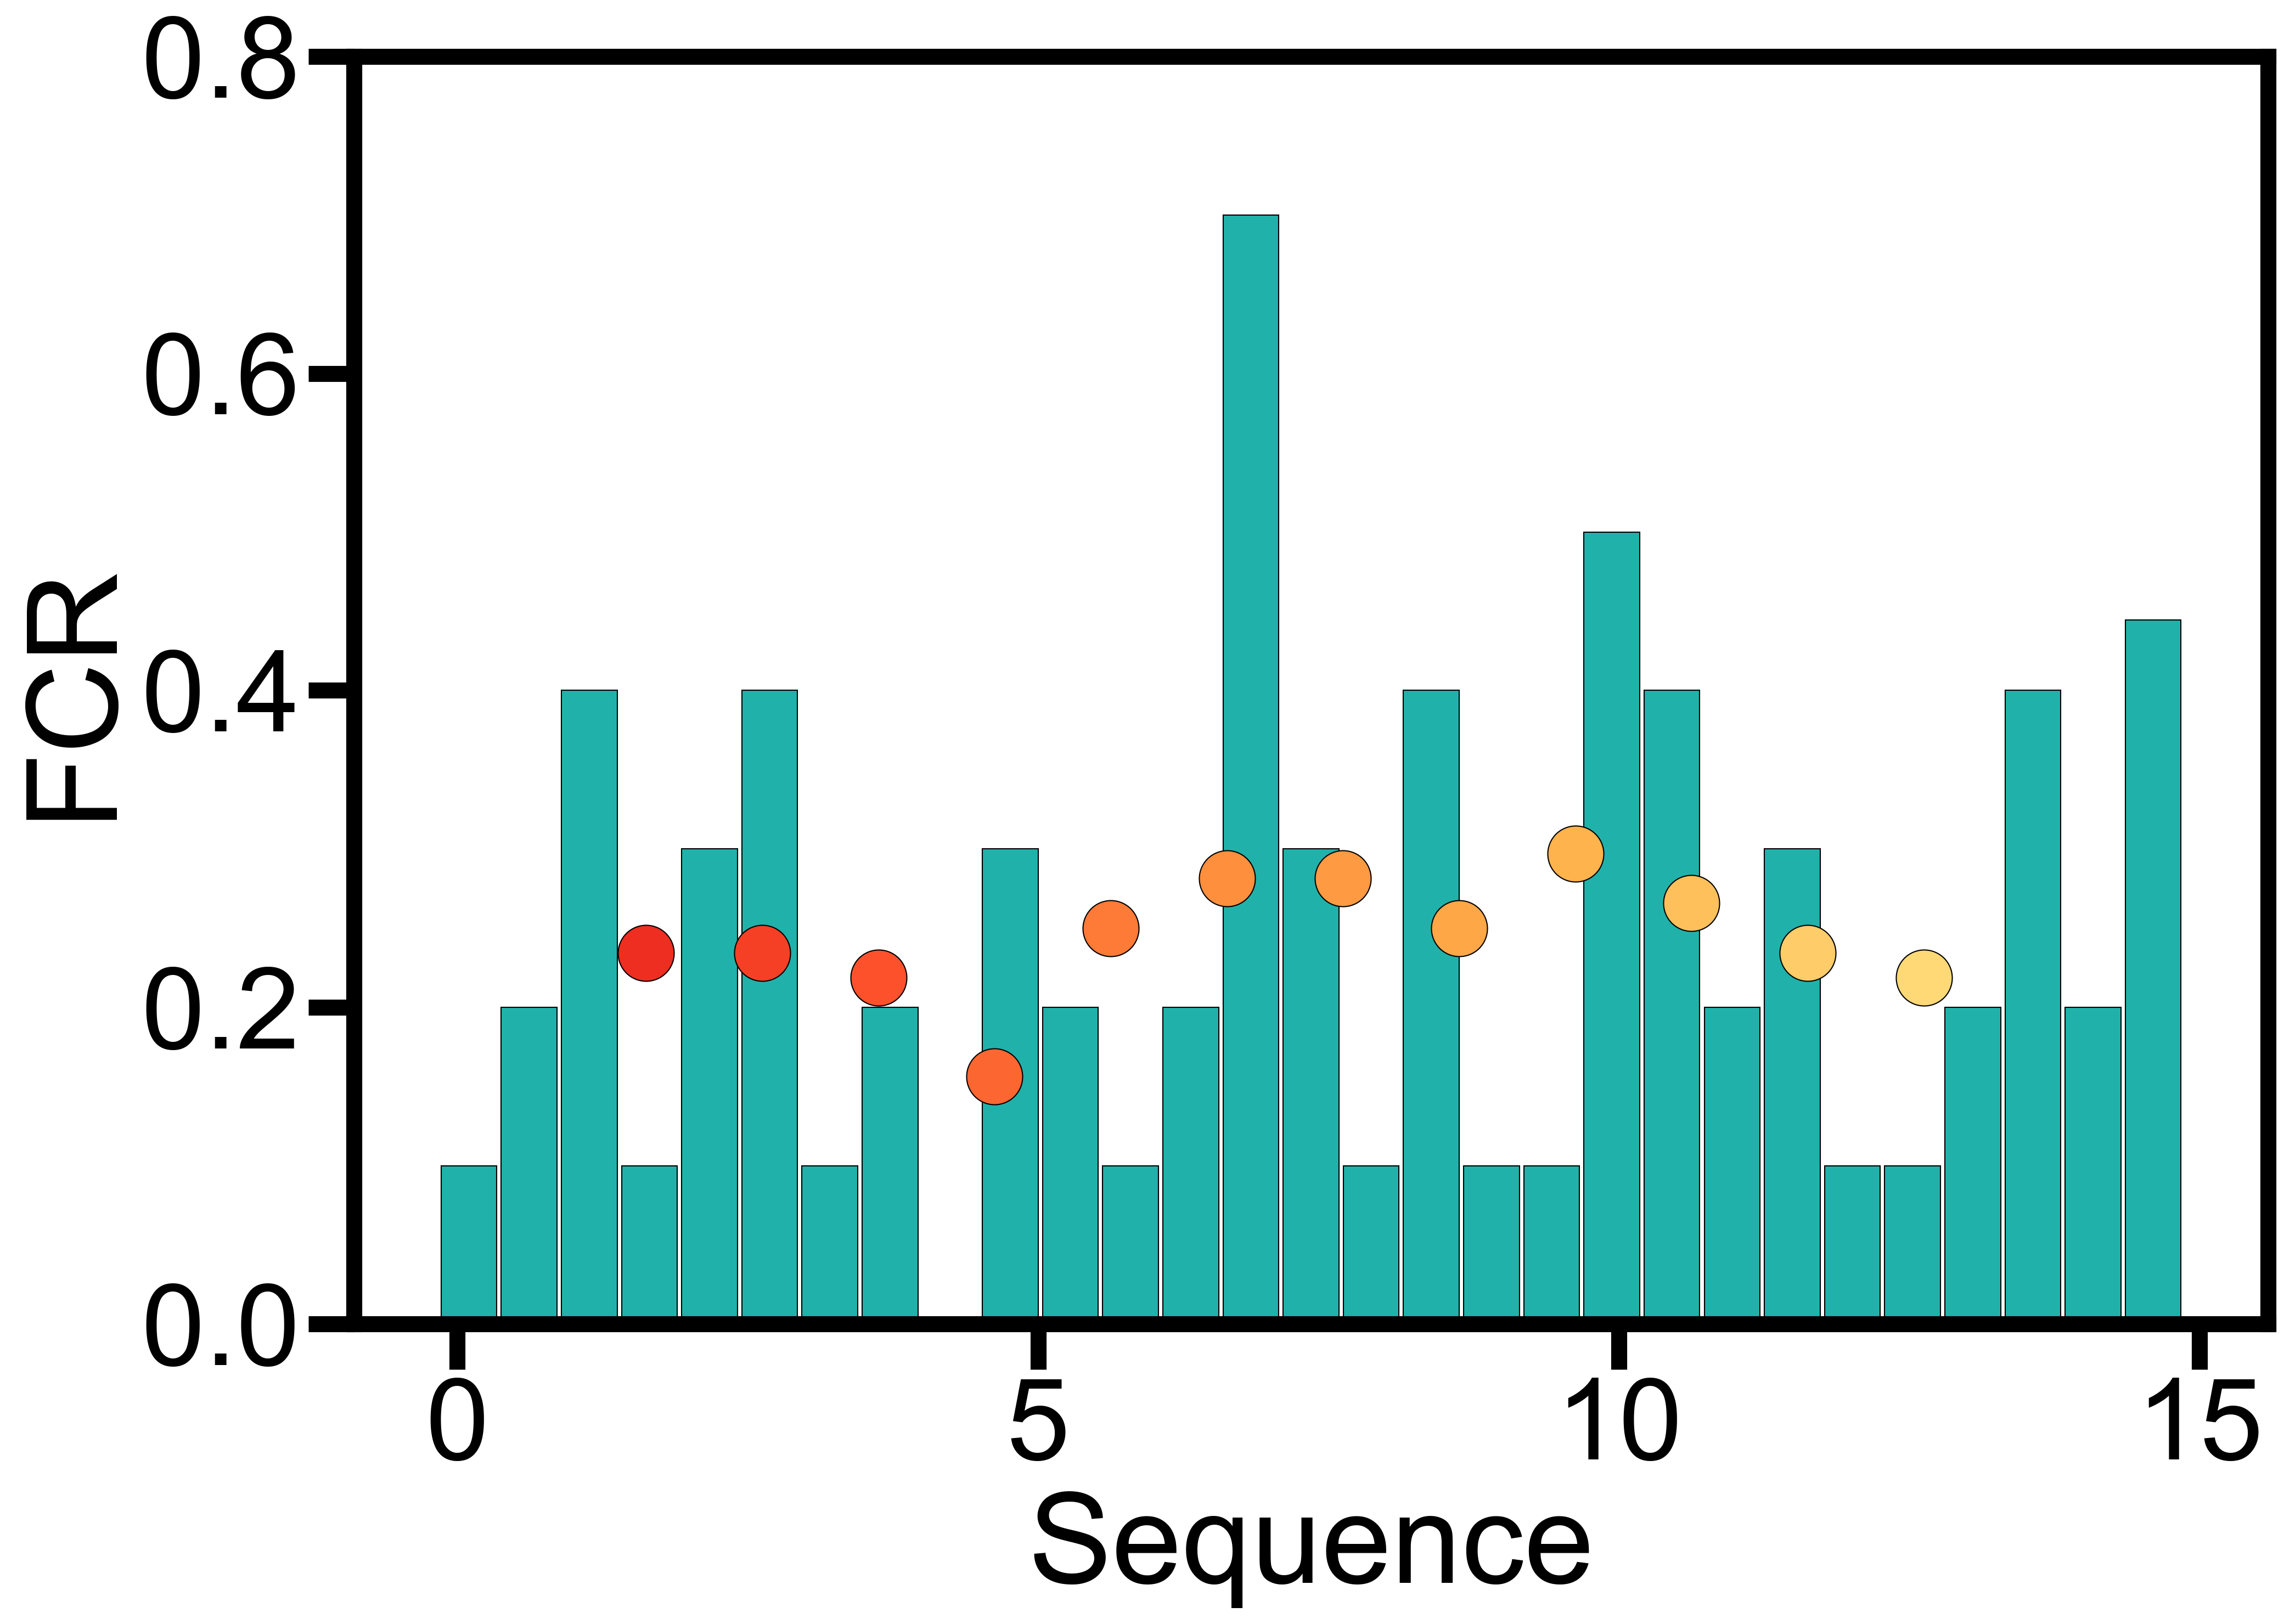

In [182]:

y = 'FCR'

fig, ax = plt.subplots(figsize=(18, 10))
colors = np.where(evaluated_df[y] >0, 'lightseagreen', 'purple')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df[y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=600, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 0.8)

plt.ylabel(y)
plt.xlabel('Sequence')

Text(0.5, 0, 'Sequence')

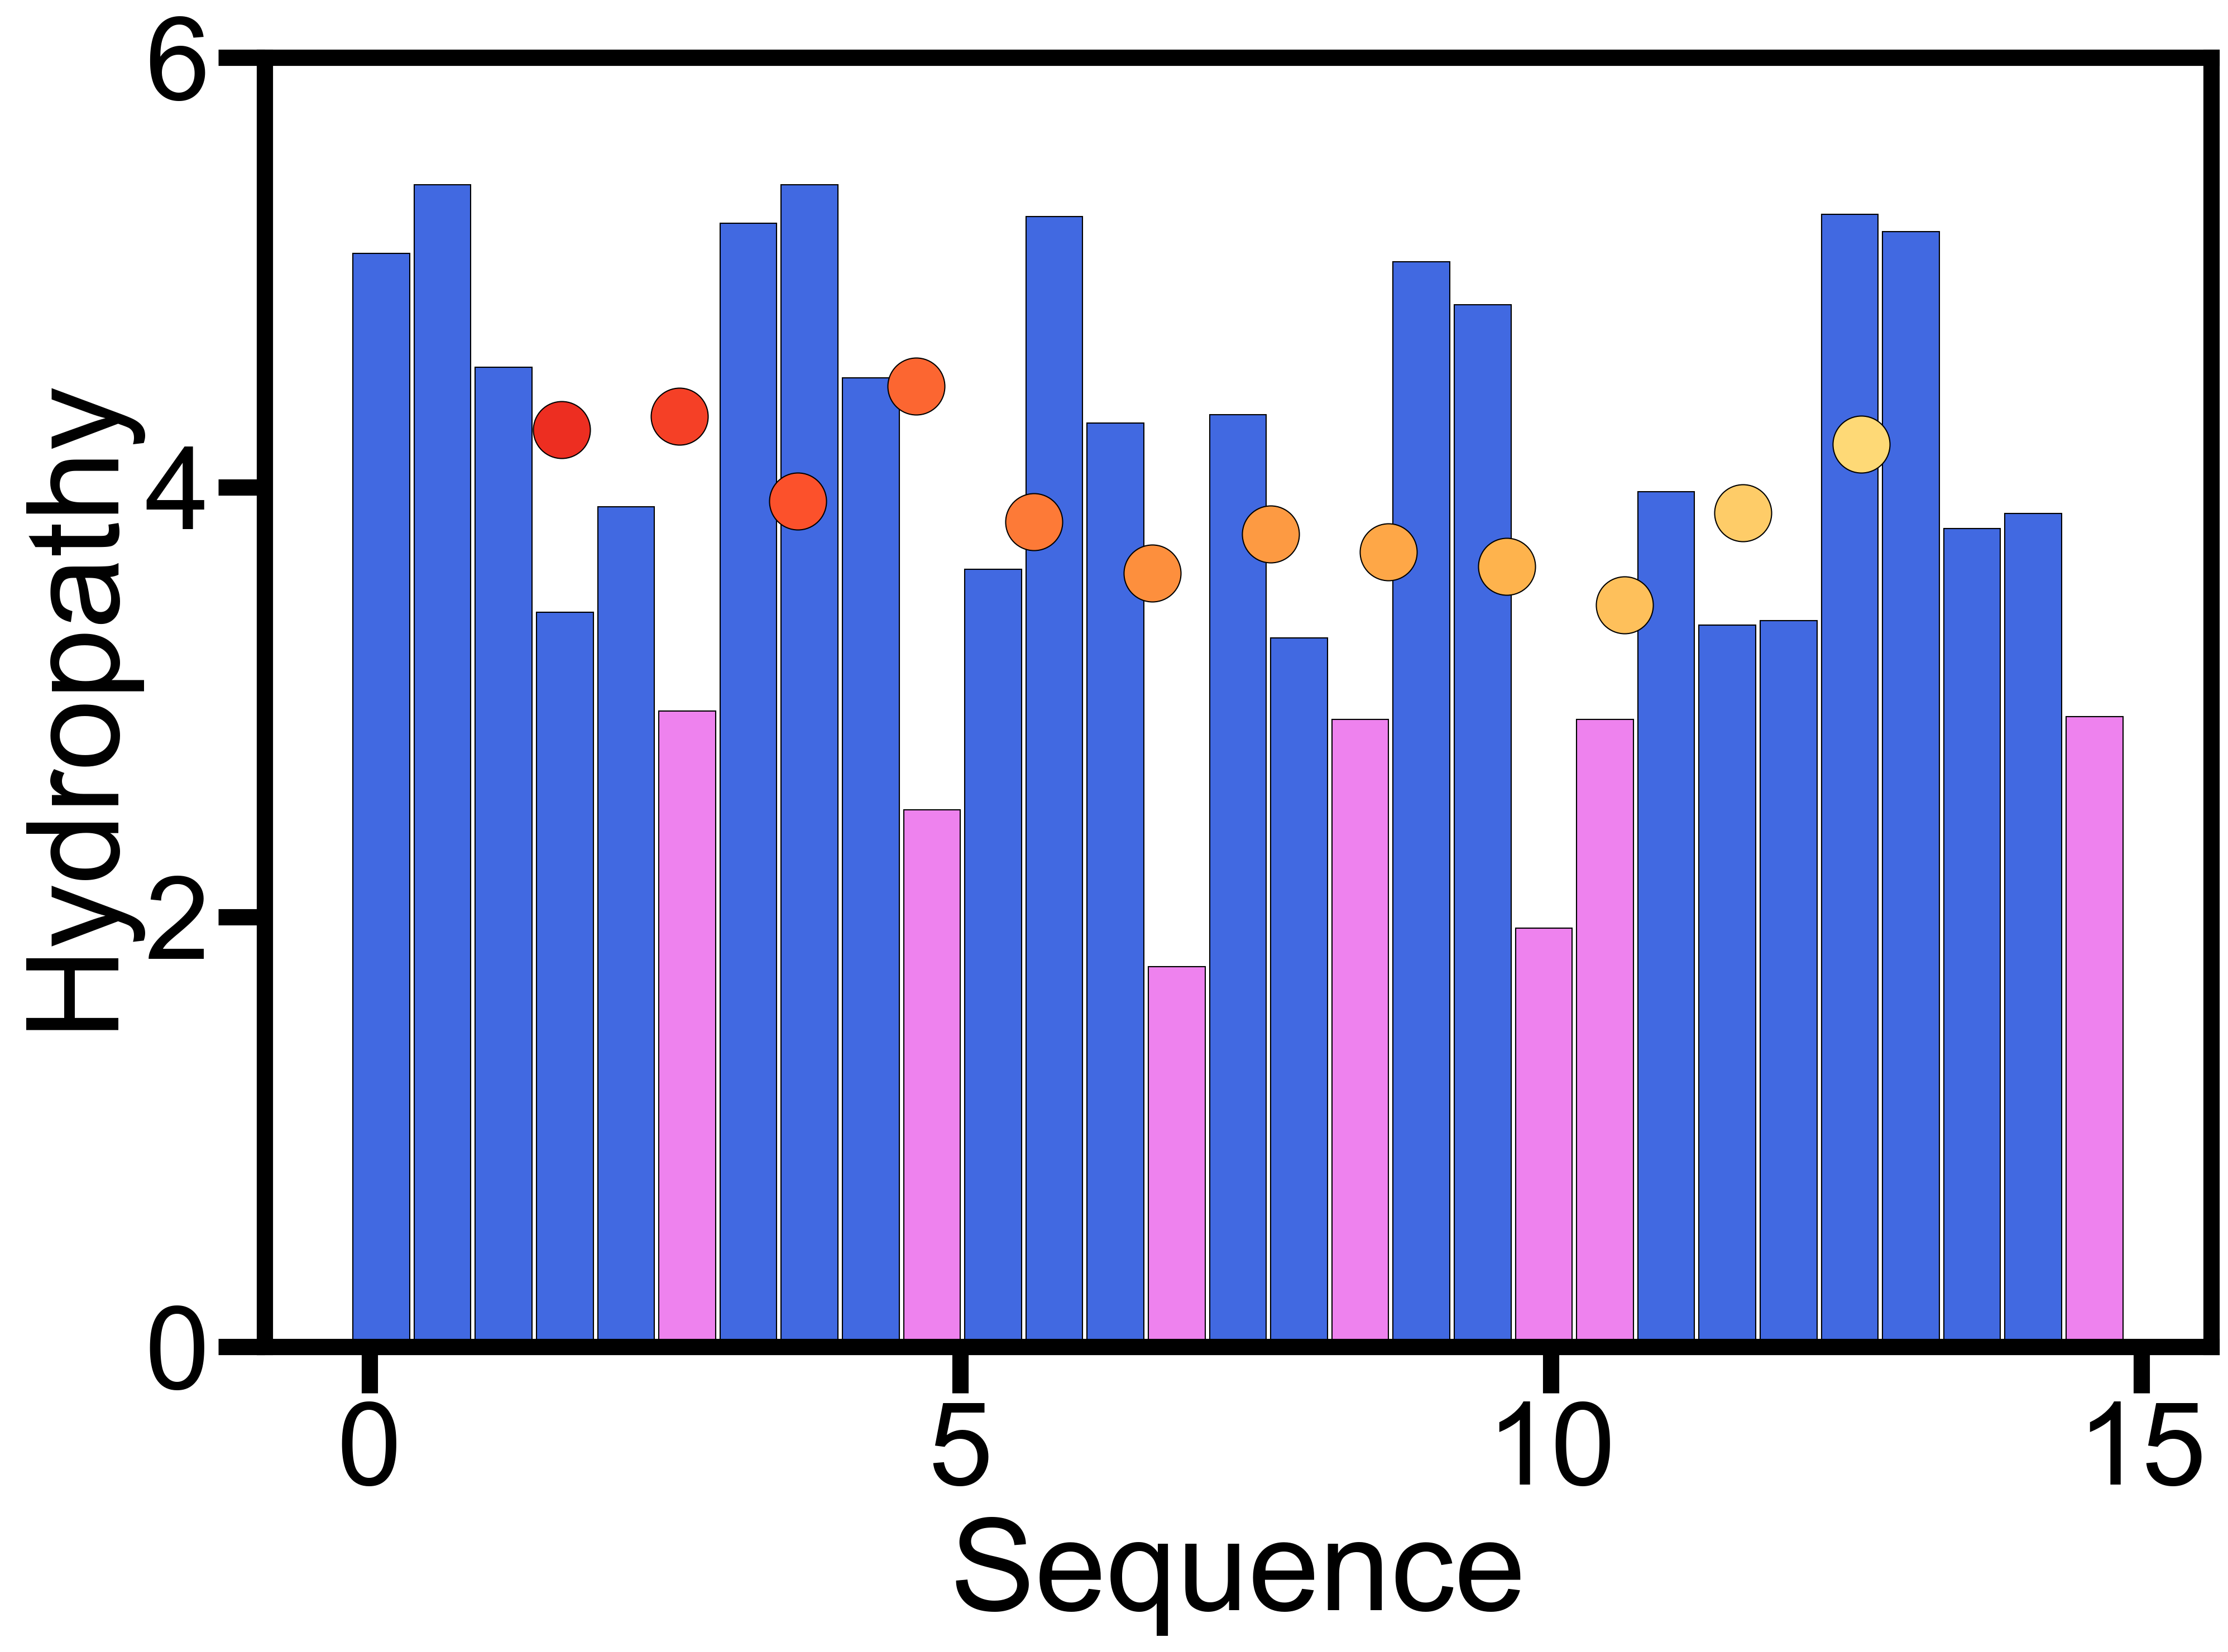

In [185]:

y = 'mean_hydropathy'

fig, ax = plt.subplots(figsize=(18, 10))
colors = np.where(evaluated_df[y] >3, 'royalblue', 'violet')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df[y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=600, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 6)

plt.ylabel('Hydropathy')
plt.xlabel('Sequence')

Text(0.5, 0, 'Sequence')

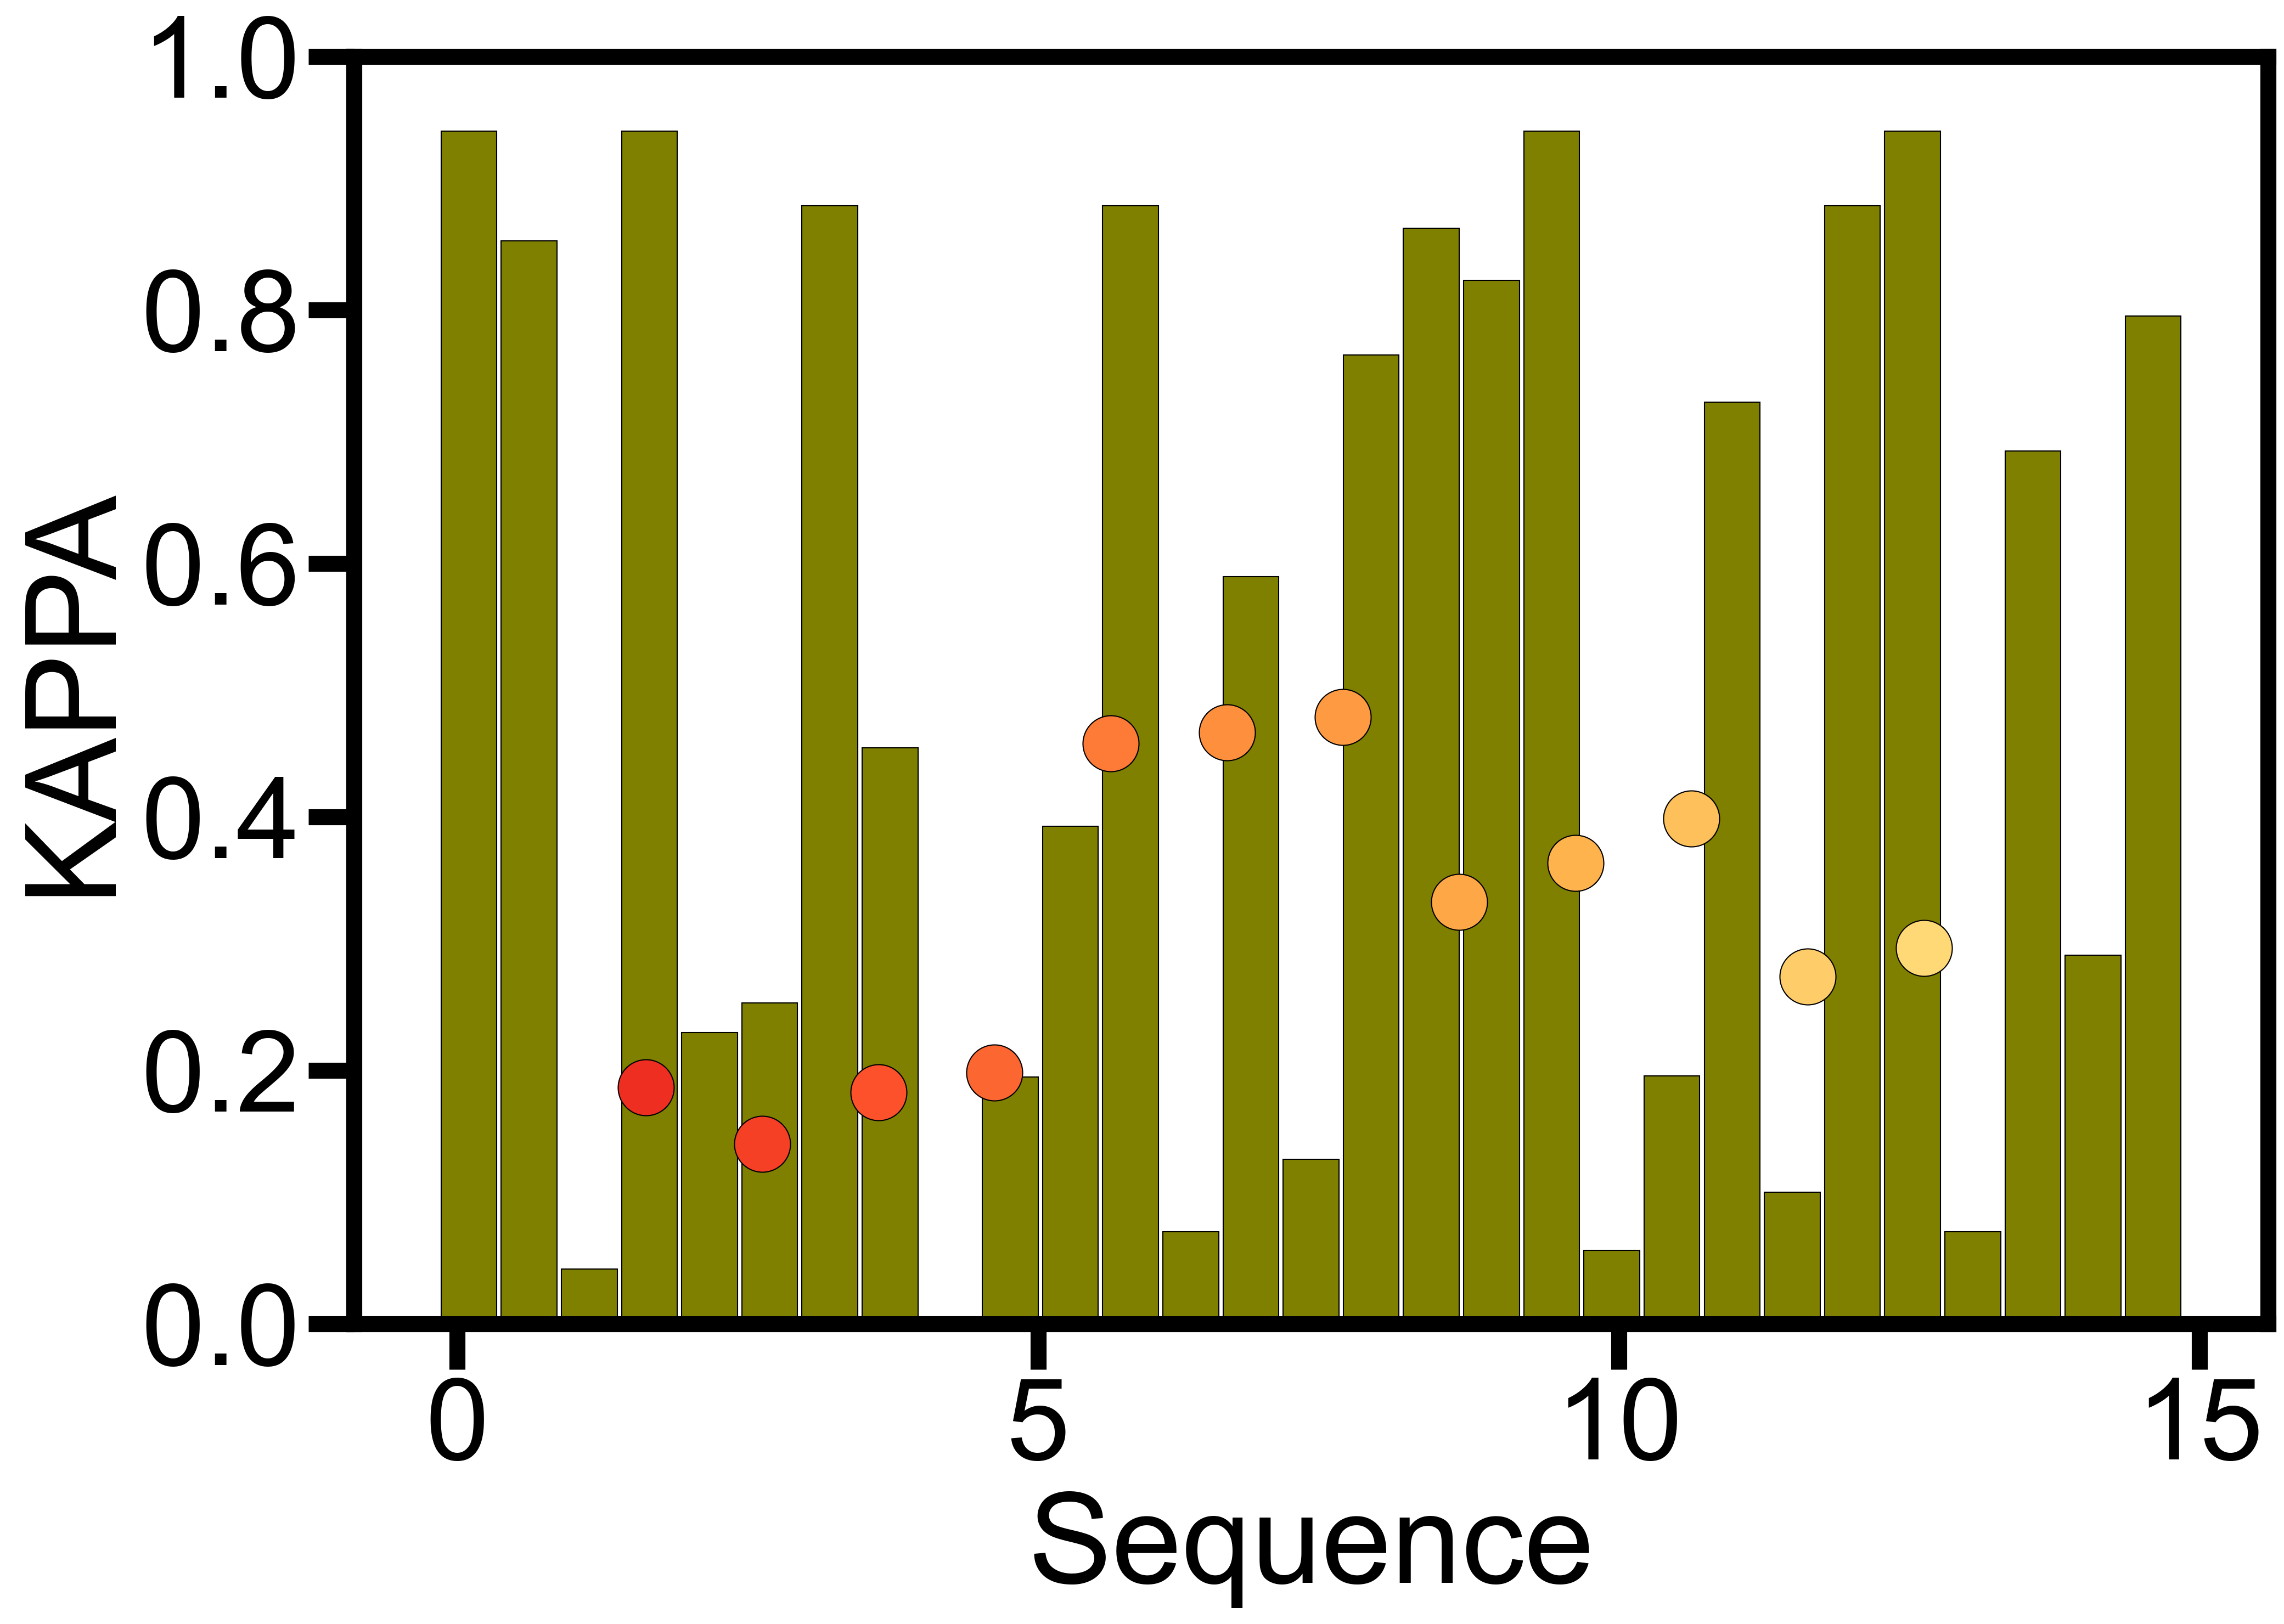

In [186]:

y = 'kappa'

fig, ax = plt.subplots(figsize=(18, 10))
colors = np.where(evaluated_df[y] >0, 'olive', 'violet')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df[y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=600, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 1)

plt.ylabel('KAPPA')
plt.xlabel('Sequence')

KeyError: 'average_ppLDDT'

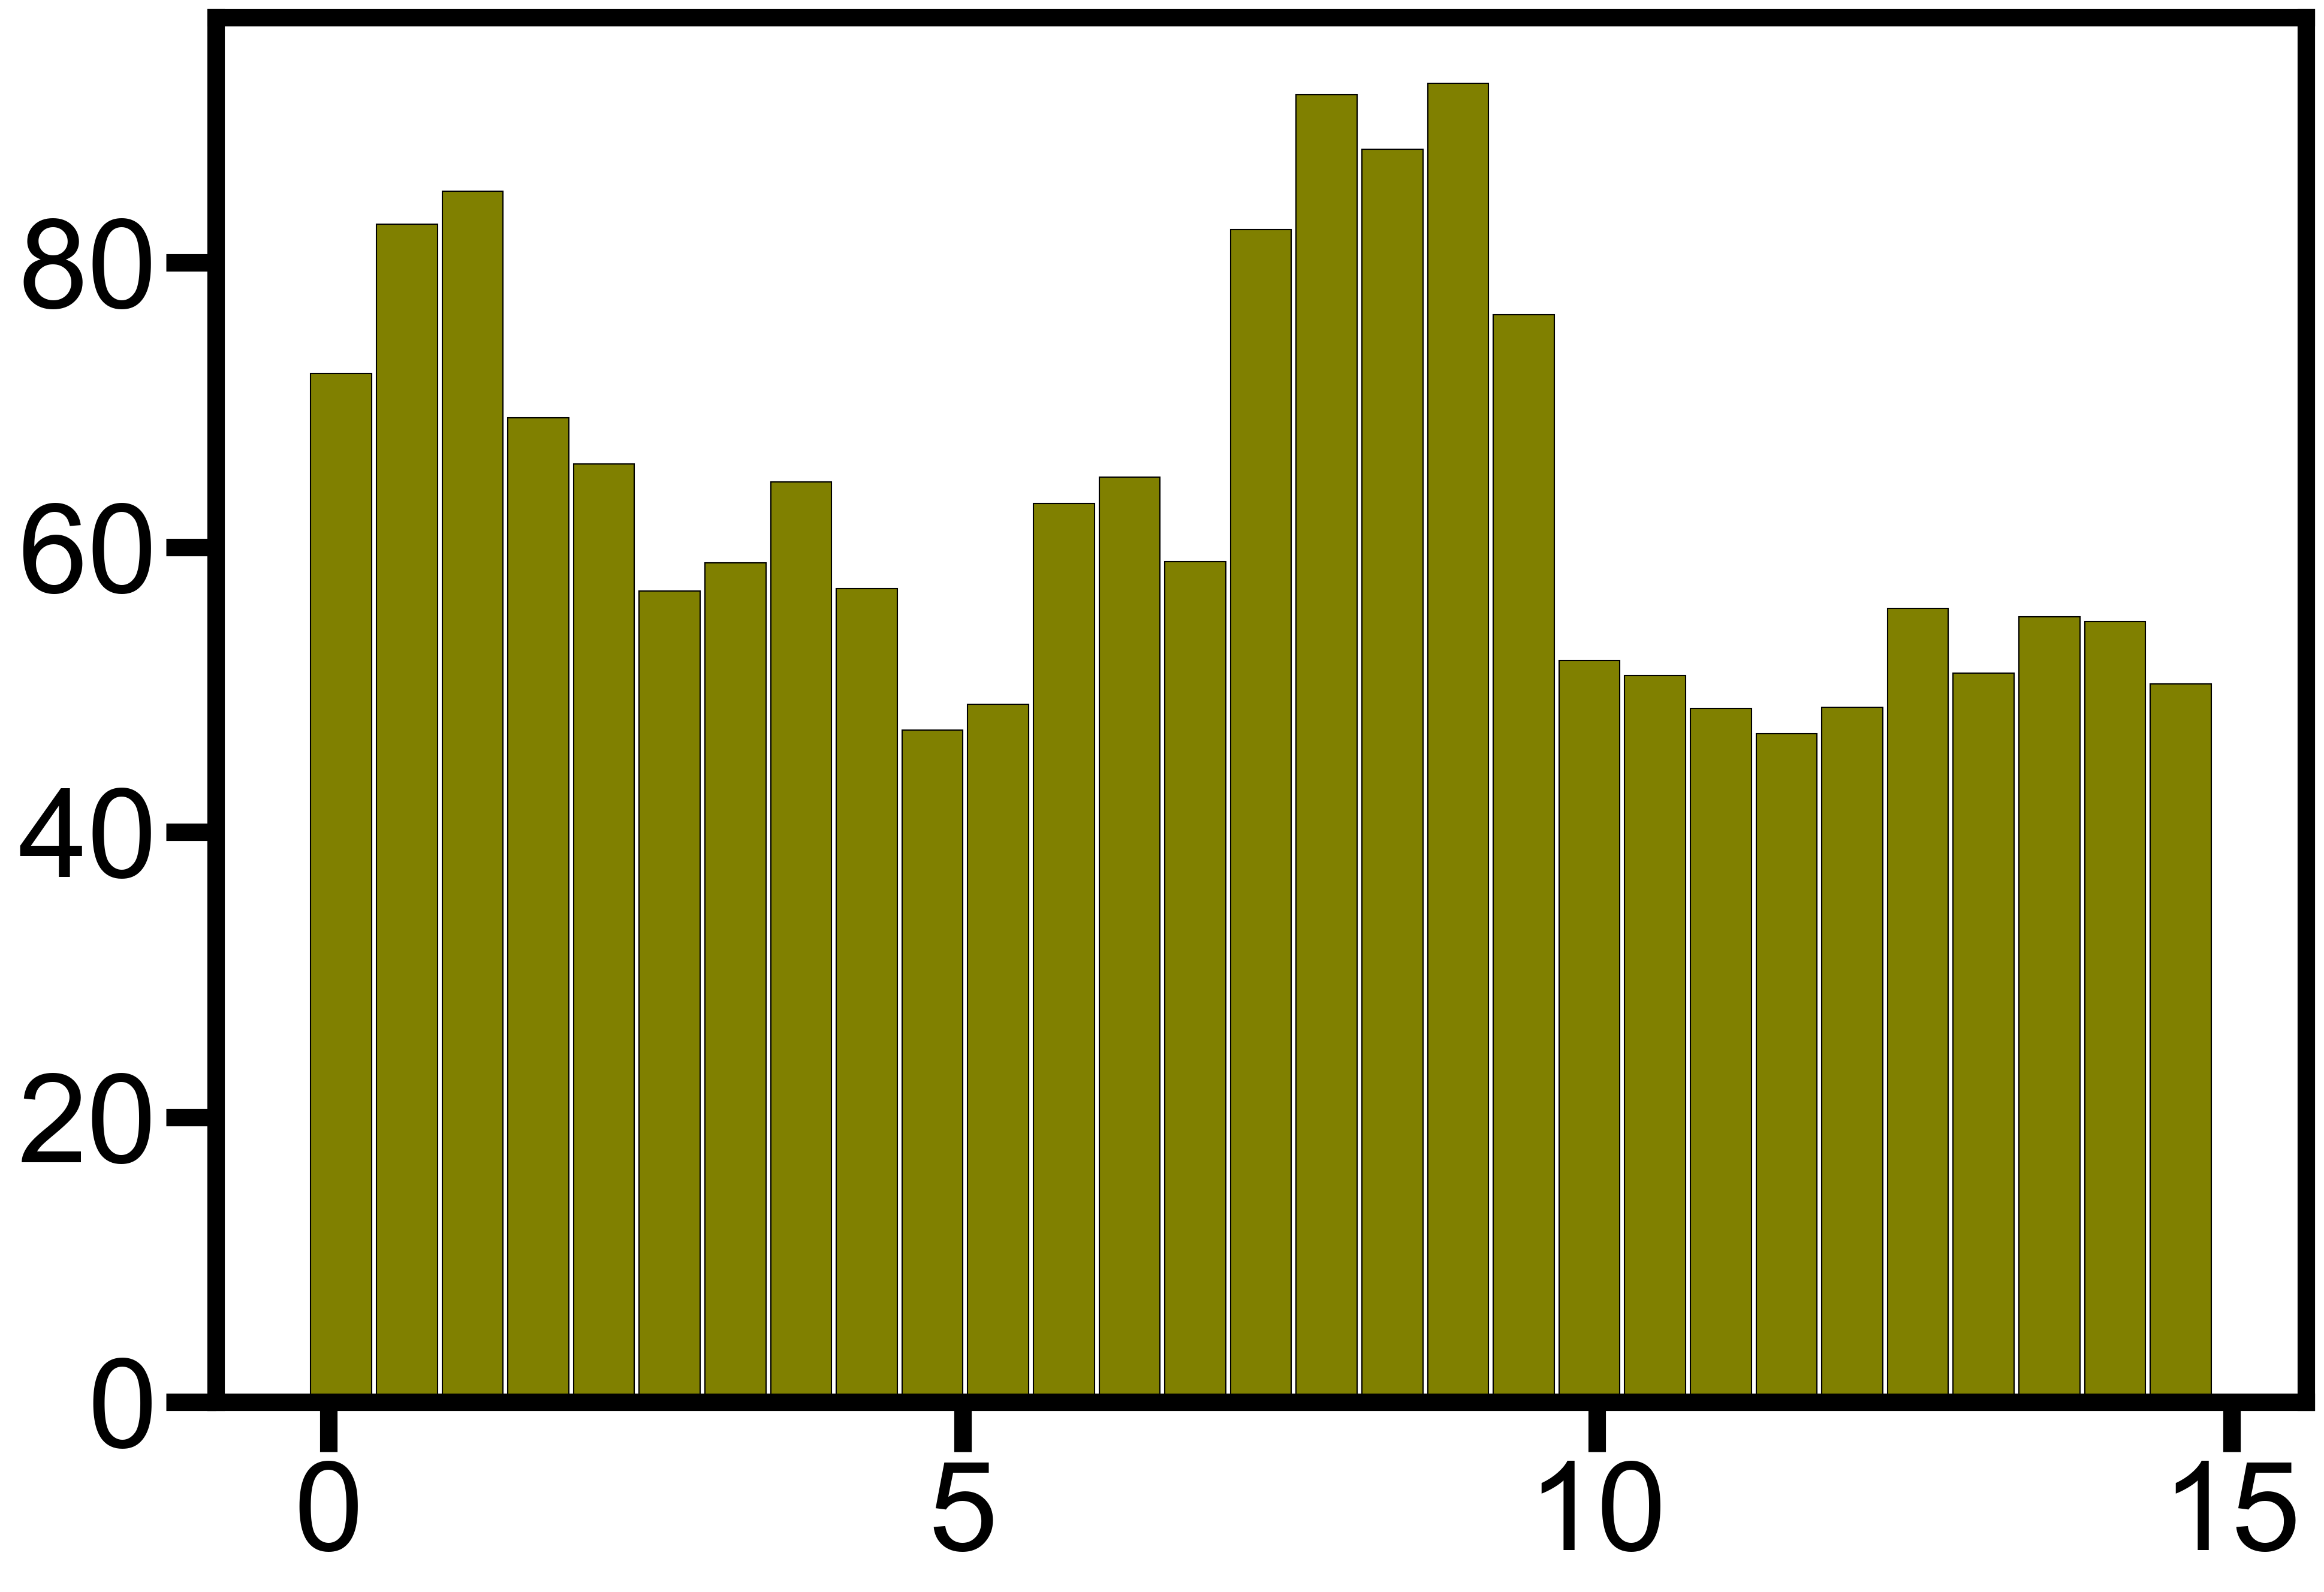

In [187]:

y = 'average_ppLDDT'

fig, ax = plt.subplots(figsize=(15, 10))
colors = np.where(evaluated_df[y] >0, 'olive', 'violet')

plt.bar(lin_space/2, evaluated_df[y], width=0.48, color=colors, zorder=2, edgecolor='k', linewidth=0.5)

N=12
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.YlOrRd(np.linspace(0.7, 0.25, N)))

comp_df = comp_df.sort_values('construct')
for i, row in enumerate(comp_df[y]):
    posit = tile_space[i]/2
    plt.scatter(posit, row, s=600, edgecolor='k', linewidth=0.5, zorder=3)
    
#plt.axhline(0, c='k')
plt.ylim(0, 1)

plt.ylabel('ppLDDT')
plt.xlabel('Sequence')

In [188]:
[[0] *3] *3

[[0, 0, 0], [0, 0, 0], [0, 0, 0]]